# QAOA vs Simulated Annealing: MaxCut Comparison
## QIntern 2026 | Project qi26_26 | Week 5

**Quantum Lead:** Shahreen Sultana  
**Classical Lead:** Kanishka  
**Mentor:** Joselyn Lagunas  

This notebook merges the quantum QAOA implementation and the classical
Simulated Annealing implementation to produce a direct side-by-side
comparison on the MaxCut problem.

# Cell 1 — Installations:

In [1]:
# ── Installations ─────────────────────────────────────────
!pip install scipy numpy matplotlib -q

# Cell 2 — Imports:

In [2]:
# ── Imports ───────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import json
import scipy.stats as stats
from datetime import datetime, timezone
import os
import urllib.request
from scipy import stats

In [3]:
# ── Publication Quality Settings ──────────────────────────
plt.style.use('seaborn-v0_8-whitegrid')
mpl.rcParams.update({
    'font.family': 'serif',
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 13,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 11,
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'savefig.format': 'png',
    'axes.linewidth': 1.2,
    'figure.figsize': (10, 6)
})
print("Settings applied!")

Settings applied!


## 1. Protocol Overview

**Problem:** MaxCut on 3-regular random graphs  
**Quantum approach:** QAOA (Quantum Approximate Optimization Algorithm)  
**Classical approach:** Simulated Annealing (SA)

**Agreed protocol (both sides):**
- Graph type: 3-regular random graphs
- Node counts: 4, 6, 8, 10 vertices
- Trials: 10 per configuration
- Metric: approximation ratio = achieved cut / optimal cut

**Quantum specific:**
- QAOA depth: p = 1, 2, 3
- Shots: 1,024 (p=1,2) | 4,096 (p=3)
- Optimizer: COBYLA

**References:**
- Farhi, Goldstone, Gutmann (2014, arXiv:1411.4028) — original QAOA paper,
  establishes 3-regular MaxCut as standard benchmark, p=1 gives 0.6924 AR
- Willsch, Willsch, Jin, De Raedt, Michielsen (2020, Quantum Information
  Processing, DOI: 10.1007/s11128-020-02692-8) — QAOA benchmarking on
  MaxCut, approximation ratio as primary metric
- Kirkpatrick, Gelatt, Vecchi (1983, Science, DOI: 10.1126/science.220.4598.671)
  — original Simulated Annealing paper, classical baseline
- Shaydulin et al. (2024, Science Advances, DOI: 10.1126/sciadv.adm6761)
  — shot count guidance and scaling analysis for QAOA

## 2. Setup and Load Results

Loading quantum (QAOA) and classical (Simulated Annealing) experiment
logs for direct comparison.

**Logging schema follows:** Measurement Framework Consolidated v1  
(docs/measurement_framework_consolidated.md)

In [5]:
# ── Load QAOA Results from GitHub ────────────────────────
BASE_URL = "https://raw.githubusercontent.com/Shel-y/qintern2026-quantum-benchmarking/main/results/quantum/qaoa/json/"

# Load all QAOA experiment logs
def load_json(url):
    with urllib.request.urlopen(url) as response:
        return json.load(response)

qaoa_benchmark = load_json(BASE_URL + "qaoa_experiment_001.json")
qaoa_layer2    = load_json(BASE_URL + "qaoa_experiment_002.json")
qaoa_perf      = load_json(BASE_URL + "qaoa_experiment_003.json")
qaoa_pertrial_raw = load_json(BASE_URL + "qaoa_experiment_004.json")

print("QAOA results loaded!")
print(f"Experiment 001: {qaoa_benchmark['experiment_id']}")
print(f"Experiment 002: {qaoa_layer2['experiment_id']}")
print(f"Experiment 003: {qaoa_perf['experiment_id']}")
print(f"Experiment 004: {qaoa_pertrial_raw['experiment_id']}")

import pandas as pd
qaoa_pertrial = qaoa_pertrial_raw['metrics']['per_trial_results']
qaoa_pertrial_df = pd.DataFrame(qaoa_pertrial)
print(f"Per-trial records loaded: {len(qaoa_pertrial)}")
print(qaoa_pertrial_df.groupby(['N', 'p'])['approx_ratio'].agg(['mean', 'std', 'count']))

QAOA results loaded!
Experiment 001: qi26_26_QAOA_001
Experiment 002: qi26_26_QAOA_002
Experiment 003: qi26_26_QAOA_003
Experiment 004: qi26_26_QAOA_004
Per-trial records loaded: 120
         mean       std  count
N  p                          
4  1  1.00000  0.000000     10
   2  1.00000  0.000000     10
   3  1.00000  0.000000     10
6  1  0.94286  0.180693     10
   2  1.00000  0.000000     10
   3  1.00000  0.000000     10
8  1  1.00000  0.000000     10
   2  0.99000  0.031623     10
   3  0.98000  0.042164     10
10 1  0.95000  0.158114     10
   2  0.99231  0.024318     10
   3  0.95193  0.087535     10


In [6]:
# ── Load SA Results from GitHub ───────────────────────────
SA_BASE_URL = "https://raw.githubusercontent.com/Shel-y/qintern2026-quantum-benchmarking/main/classical_implementations/Classical_MaxCutSolver/"

sa_raw = load_json(SA_BASE_URL + "simulated_annealing_summary.json")

# Extract into consistent format
sa_results = []
for r in sa_raw:
    sa_results.append({
        'N': r['Nodes'],
        'mean_runtime': r['Runtime (s)_mean'],
        'std_runtime': r['Runtime (s)_std'],
        'mean_best_cut': r['Best Cut_mean'],
        'std_best_cut': r['Best Cut_std'],
        'mean_approx_ratio': r['Approximation Ratio_mean'],
        'std_approx_ratio': r['Approximation Ratio_std'],
        'mean_cpu_time': r['CPU Time (s)_mean'],
        'mean_ram_mb': r['Peak RAM (MB)_mean']
    })

print("SA results loaded!")
print(f"\n{'N':>4} | {'Mean AR':>8} | {'Mean RT(s)':>12} | {'Best Cut':>10}")
print("-" * 42)
for r in sa_results:
    print(f"{r['N']:>4} | {r['mean_approx_ratio']:>8.4f} | "
          f"{r['mean_runtime']:>12.5f} | {r['mean_best_cut']:>10.1f}")

SA results loaded!

   N |  Mean AR |   Mean RT(s) |   Best Cut
------------------------------------------
   4 |   1.0000 |      0.01110 |        4.0
   6 |   1.0000 |      0.01580 |        7.2
   8 |   1.0000 |      0.02183 |       10.4
  10 |   1.0000 |      0.04308 |       12.9


In [7]:
# ── Extract QAOA Results ──────────────────────────────────

# Benchmark results (N, p, mean AR, std, runtime)
qaoa_results = qaoa_benchmark['metrics']['results']

# Performance results
qaoa_perf_data = qaoa_perf['metrics']['performance']

# Configuration
NODE_COUNTS = qaoa_benchmark['protocol']['node_counts']
P_VALUES = qaoa_benchmark['protocol']['p_values']

print("QAOA Configuration:")
print(f"Node counts: {NODE_COUNTS}")
print(f"P values: {P_VALUES}")
print(f"Trials: {qaoa_benchmark['protocol']['trials']}")
print(f"Graph type: {qaoa_benchmark['protocol']['graph_type']}")
print(f"\nResults loaded: {len(qaoa_results)} configurations")
print(f"Performance data: {len(qaoa_perf_data)} configurations")

# Quick summary
print("\nQuick Summary:")
print(f"{'N':>4} | {'p':>2} | {'Mean AR':>8} | {'Std':>6} | {'Runtime(s)':>10}")
print("-" * 40)
for r in qaoa_results:
    print(f"{r['N']:>4} | {r['p']:>2} | {r['mean_approx_ratio']:>8.4f} | "
          f"{r['std']:>6.4f} | {r['mean_runtime']:>10.4f}")

QAOA Configuration:
Node counts: [4, 6, 8, 10]
P values: [1, 2, 3]
Trials: 10
Graph type: 3-regular random

Results loaded: 12 configurations
Performance data: 12 configurations

Quick Summary:
   N |  p |  Mean AR |    Std | Runtime(s)
----------------------------------------
   4 |  1 |   1.0000 | 0.0000 |     1.1737
   4 |  2 |   1.0000 | 0.0000 |     2.3620
   4 |  3 |   1.0000 | 0.0000 |     5.2153
   6 |  1 |   0.9429 | 0.1714 |     1.3066
   6 |  2 |   1.0000 | 0.0000 |     3.0949
   6 |  3 |   1.0000 | 0.0000 |     7.5885
   8 |  1 |   1.0000 | 0.0000 |     1.9147
   8 |  2 |   0.9900 | 0.0300 |     3.6054
   8 |  3 |   0.9800 | 0.0400 |     9.8007
  10 |  1 |   0.9500 | 0.1500 |     1.9839
  10 |  2 |   0.9923 | 0.0231 |     5.1629
  10 |  3 |   0.9519 | 0.0830 |    12.2693


In [8]:
# ── Prepare Comparison Data ───────────────────────────────
print("=" * 60)
print("QAOA vs Simulated Annealing: Direct Comparison")
print("=" * 60)

print(f"\n{'N':>4} | {'QAOA AR':>8} | {'SA AR':>8} | {'QAOA RT(s)':>12} | {'SA RT(s)':>10} | {'Winner':>8}")
print("-" * 65)

comparison_data = []
for N in NODE_COUNTS:
    # Best QAOA result across all p values
    qaoa_best = max([r for r in qaoa_results if r['N'] == N],
                    key=lambda x: x['mean_approx_ratio'])
    sa = next(r for r in sa_results if r['N'] == N)

    qaoa_ar = qaoa_best['mean_approx_ratio']
    sa_ar = sa['mean_approx_ratio']
    qaoa_rt = qaoa_best['mean_runtime']
    sa_rt = sa['mean_runtime']

    ar_winner = 'QAOA' if qaoa_ar > sa_ar else ('SA' if sa_ar > qaoa_ar else 'TIE')
    rt_winner = 'QAOA' if qaoa_rt < sa_rt else 'SA'

    comparison_data.append({
        'N': N,
        'qaoa_ar': qaoa_ar,
        'sa_ar': sa_ar,
        'qaoa_rt': qaoa_rt,
        'sa_rt': sa_rt,
        'ar_winner': ar_winner,
        'rt_winner': rt_winner
    })

    print(f"{N:>4} | {qaoa_ar:>8.4f} | {sa_ar:>8.4f} | "
          f"{qaoa_rt:>12.4f} | {sa_rt:>10.5f} | {ar_winner:>8}")

print("\nNote: QAOA best p value used for each N")
print("Runtime: SA is significantly faster than QAOA at all sizes")

QAOA vs Simulated Annealing: Direct Comparison

   N |  QAOA AR |    SA AR |   QAOA RT(s) |   SA RT(s) |   Winner
-----------------------------------------------------------------
   4 |   1.0000 |   1.0000 |       1.1737 |    0.01110 |      TIE
   6 |   1.0000 |   1.0000 |       3.0949 |    0.01580 |      TIE
   8 |   1.0000 |   1.0000 |       1.9147 |    0.02183 |      TIE
  10 |   0.9923 |   1.0000 |       5.1629 |    0.04308 |       SA

Note: QAOA best p value used for each N
Runtime: SA is significantly faster than QAOA at all sizes


## 3. Approximation Ratio Comparison

Direct side-by-side comparison of mean approximation ratio across all
node counts and QAOA depths vs Simulated Annealing.

**Metric definition:**  
Approximation ratio = achieved cut value / optimal cut value  
Range: [0, 1] where 1.0 = optimal solution found

**Reference:** Willsch et al. (2020, Quantum Information Processing) use
approximation ratio as the primary quality metric for QAOA benchmarking.
Larkin, Jonsson, Justice, Guerreschi (2022, Quantum Science and Technology,
DOI: 10.1088/2058-9565/ac6973) evaluate QAOA based on the approximation
ratio of individual samples across multiple trials — same approach used here.

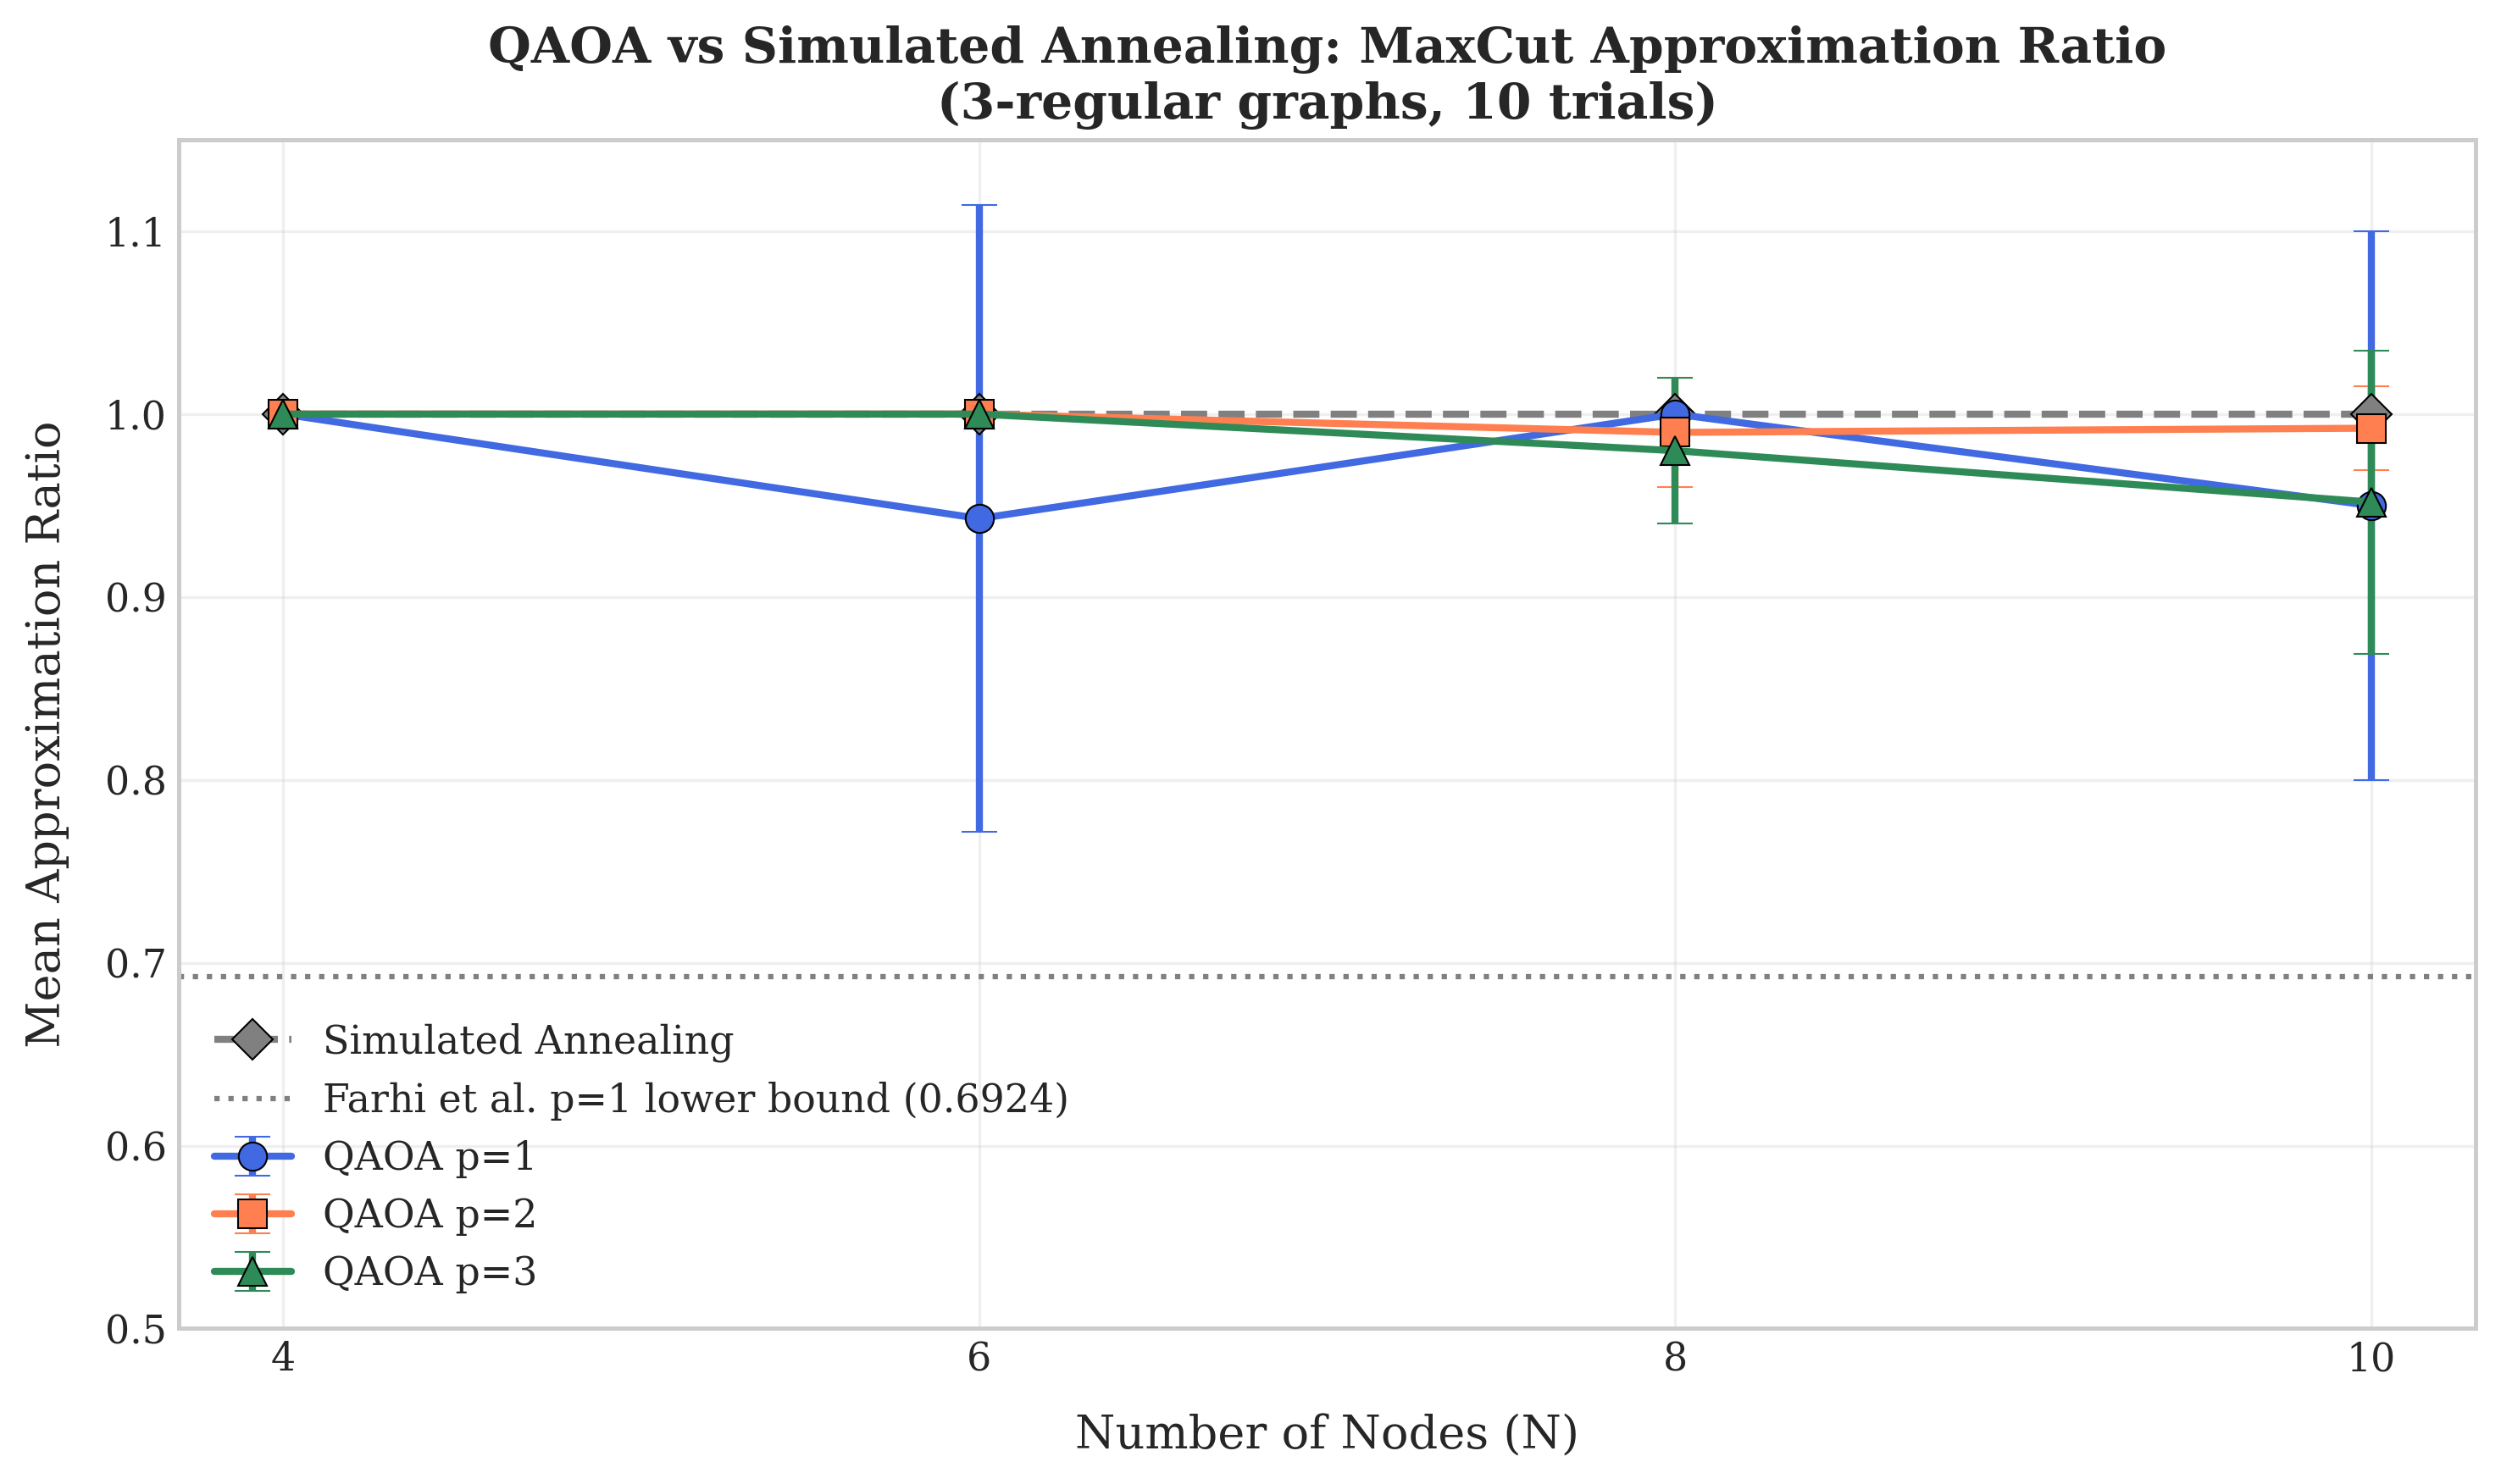

AR comparison plot saved!


In [9]:
# ── Plot: AR Comparison (QAOA only for now) ───────────────
import matplotlib.pyplot as plt
import numpy as np

NODE_COUNTS = [4, 6, 8, 10]
P_VALUES = [1, 2, 3]
colors_p = {1: 'royalblue', 2: 'coral', 3: 'seagreen'}
markers_p = {1: 'o', 2: 's', 3: '^'}

fig, ax = plt.subplots(figsize=(10, 6))

# Plot QAOA results
for p in P_VALUES:
    p_results = [r for r in qaoa_results if r['p'] == p]
    nodes = [r['N'] for r in p_results]
    mean_ar = [r['mean_approx_ratio'] for r in p_results]
    std_ar = [r['std'] for r in p_results]

    ax.errorbar(nodes, mean_ar, yerr=std_ar,
                fmt=f'{markers_p[p]}-', color=colors_p[p],
                linewidth=2, markersize=8, capsize=5,
                markeredgecolor='black', markeredgewidth=0.5,
                label=f'QAOA p={p}')

# SA results — now available!
sa_ar_p1 = [r['mean_approx_ratio'] for r in sa_results]
ax.plot(NODE_COUNTS, sa_ar_p1, 'D--', color='gray',
        linewidth=2, markersize=8,
        markeredgecolor='black', markeredgewidth=0.5,
        label='Simulated Annealing')

ax.axhline(y=0.6924, color='gray', linestyle=':',
           linewidth=1.5, label='Farhi et al. p=1 lower bound (0.6924)')
ax.set_xlabel('Number of Nodes (N)', labelpad=10)
ax.set_ylabel('Mean Approximation Ratio', labelpad=10)
ax.set_title('QAOA vs Simulated Annealing: MaxCut Approximation Ratio\n'
             '(3-regular graphs, 10 trials)',
             fontweight='bold')
ax.set_xticks(NODE_COUNTS)
ax.set_ylim(0.5, 1.15)
ax.legend(framealpha=0.9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('qaoa_comparison_ar.png', dpi=300, bbox_inches='tight')
plt.show()
print("AR comparison plot saved!")

### 3.1 Approximation Ratio by Node Count

Mean approximation ratio across 10 trials per configuration, shown for
each node count N = 4, 6, 8, 10.

Error bars show standard deviation across trials.

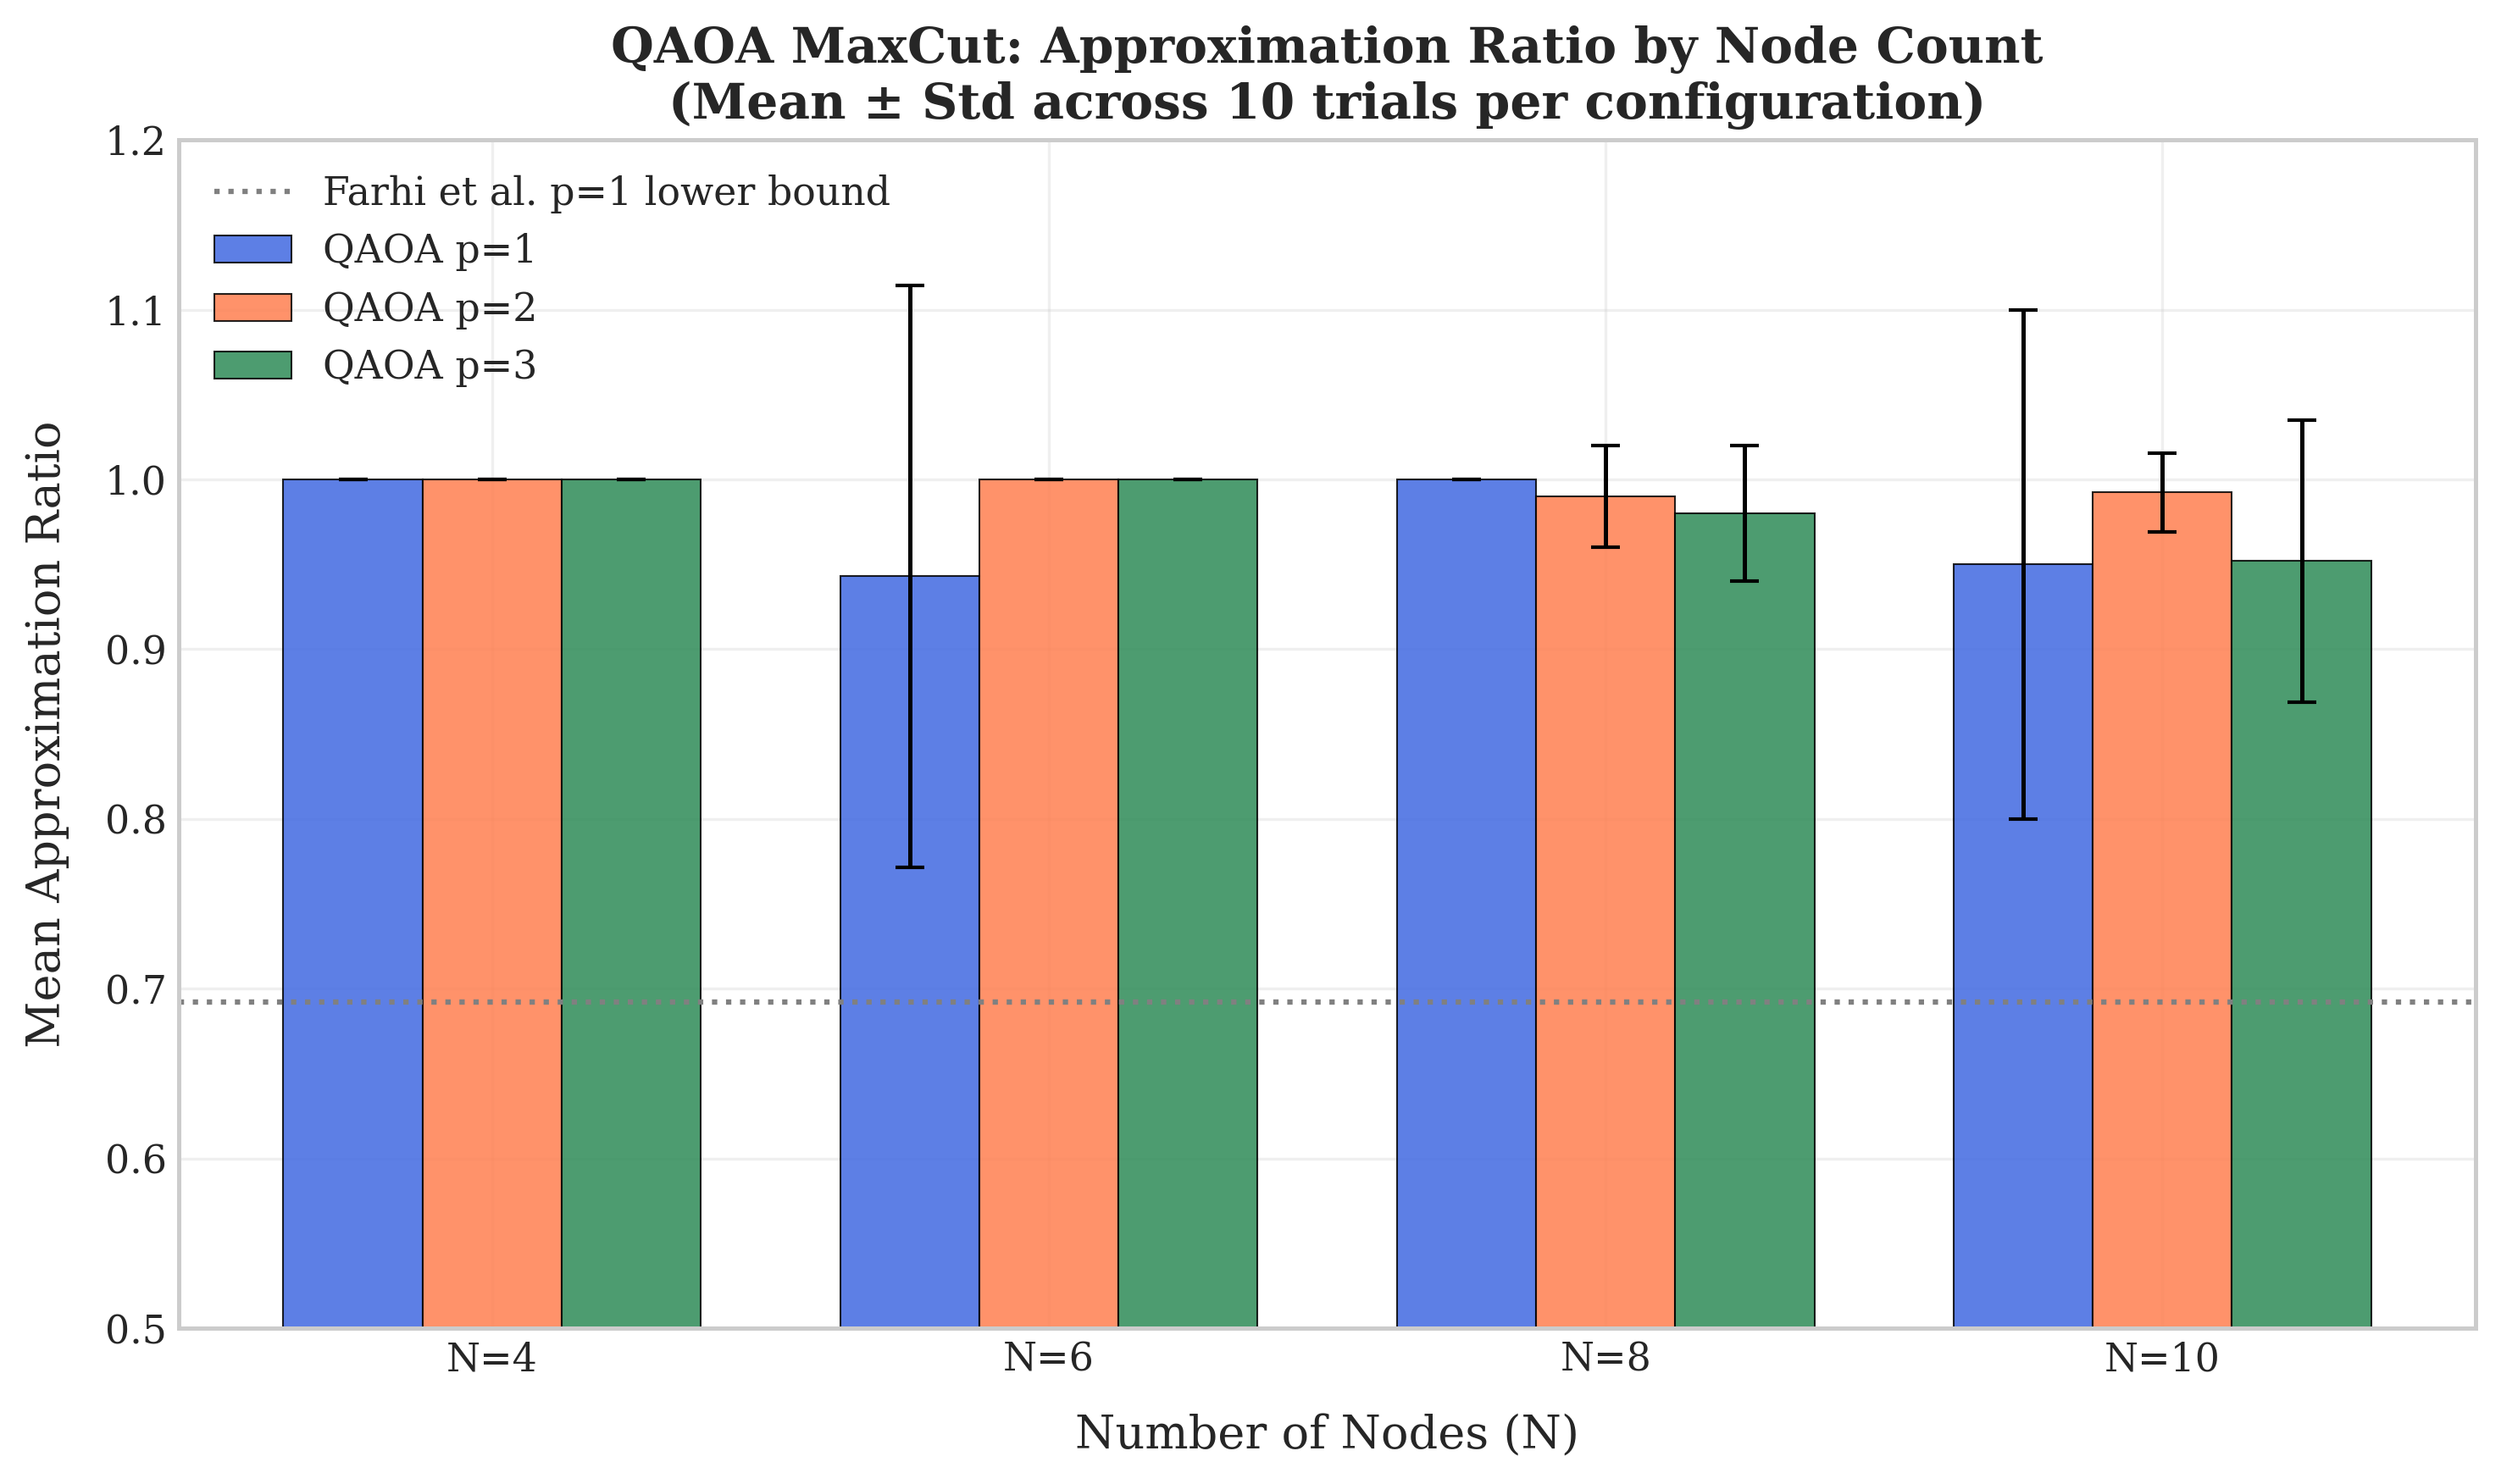

Plot 3.1 saved!


In [10]:
# ── Plot 3.1: AR by Node Count ────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(NODE_COUNTS))
width = 0.25

for idx, p in enumerate(P_VALUES):
    p_results = [r for r in qaoa_results if r['p'] == p]
    mean_ar = [r['mean_approx_ratio'] for r in p_results]
    std_ar = [r['std'] for r in p_results]

    bars = ax.bar(x + (idx - 1) * width, mean_ar, width,
                  label=f'QAOA p={p}',
                  color=list(colors_p.values())[idx],
                  alpha=0.85, edgecolor='black', linewidth=0.5)
    ax.errorbar(x + (idx - 1) * width, mean_ar, yerr=std_ar,
                fmt='none', color='black', capsize=4, linewidth=1.2)

ax.axhline(y=0.6924, color='gray', linestyle=':',
           linewidth=1.5, label='Farhi et al. p=1 lower bound')
ax.set_xlabel('Number of Nodes (N)', labelpad=10)
ax.set_ylabel('Mean Approximation Ratio', labelpad=10)
ax.set_title('QAOA MaxCut: Approximation Ratio by Node Count\n'
             '(Mean ± Std across 10 trials per configuration)',
             fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([f'N={n}' for n in NODE_COUNTS])
ax.set_ylim(0.5, 1.2)
ax.legend(framealpha=0.9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('qaoa_comparison_ar_by_node.png', dpi=300, bbox_inches='tight')
plt.show()
print("Plot 3.1 saved!")

### 3.2 Approximation Ratio by QAOA Depth (p)

QAOA performance varies with circuit depth p. Higher p generally achieves
better approximation ratios at the cost of longer runtime.

**Theoretical lower bounds (Farhi et al. 2014):**
- p=1: AR ≥ 0.6924 on 3-regular graphs
- p=2: AR ≥ 0.7559 on 3-regular graphs

**Reference:** Wurtz and Love (2021, arXiv:2107.00677) provide fixed angle
conjecture for QAOA on regular MaxCut graphs — numerical evidence that
performance guarantees increase with p.

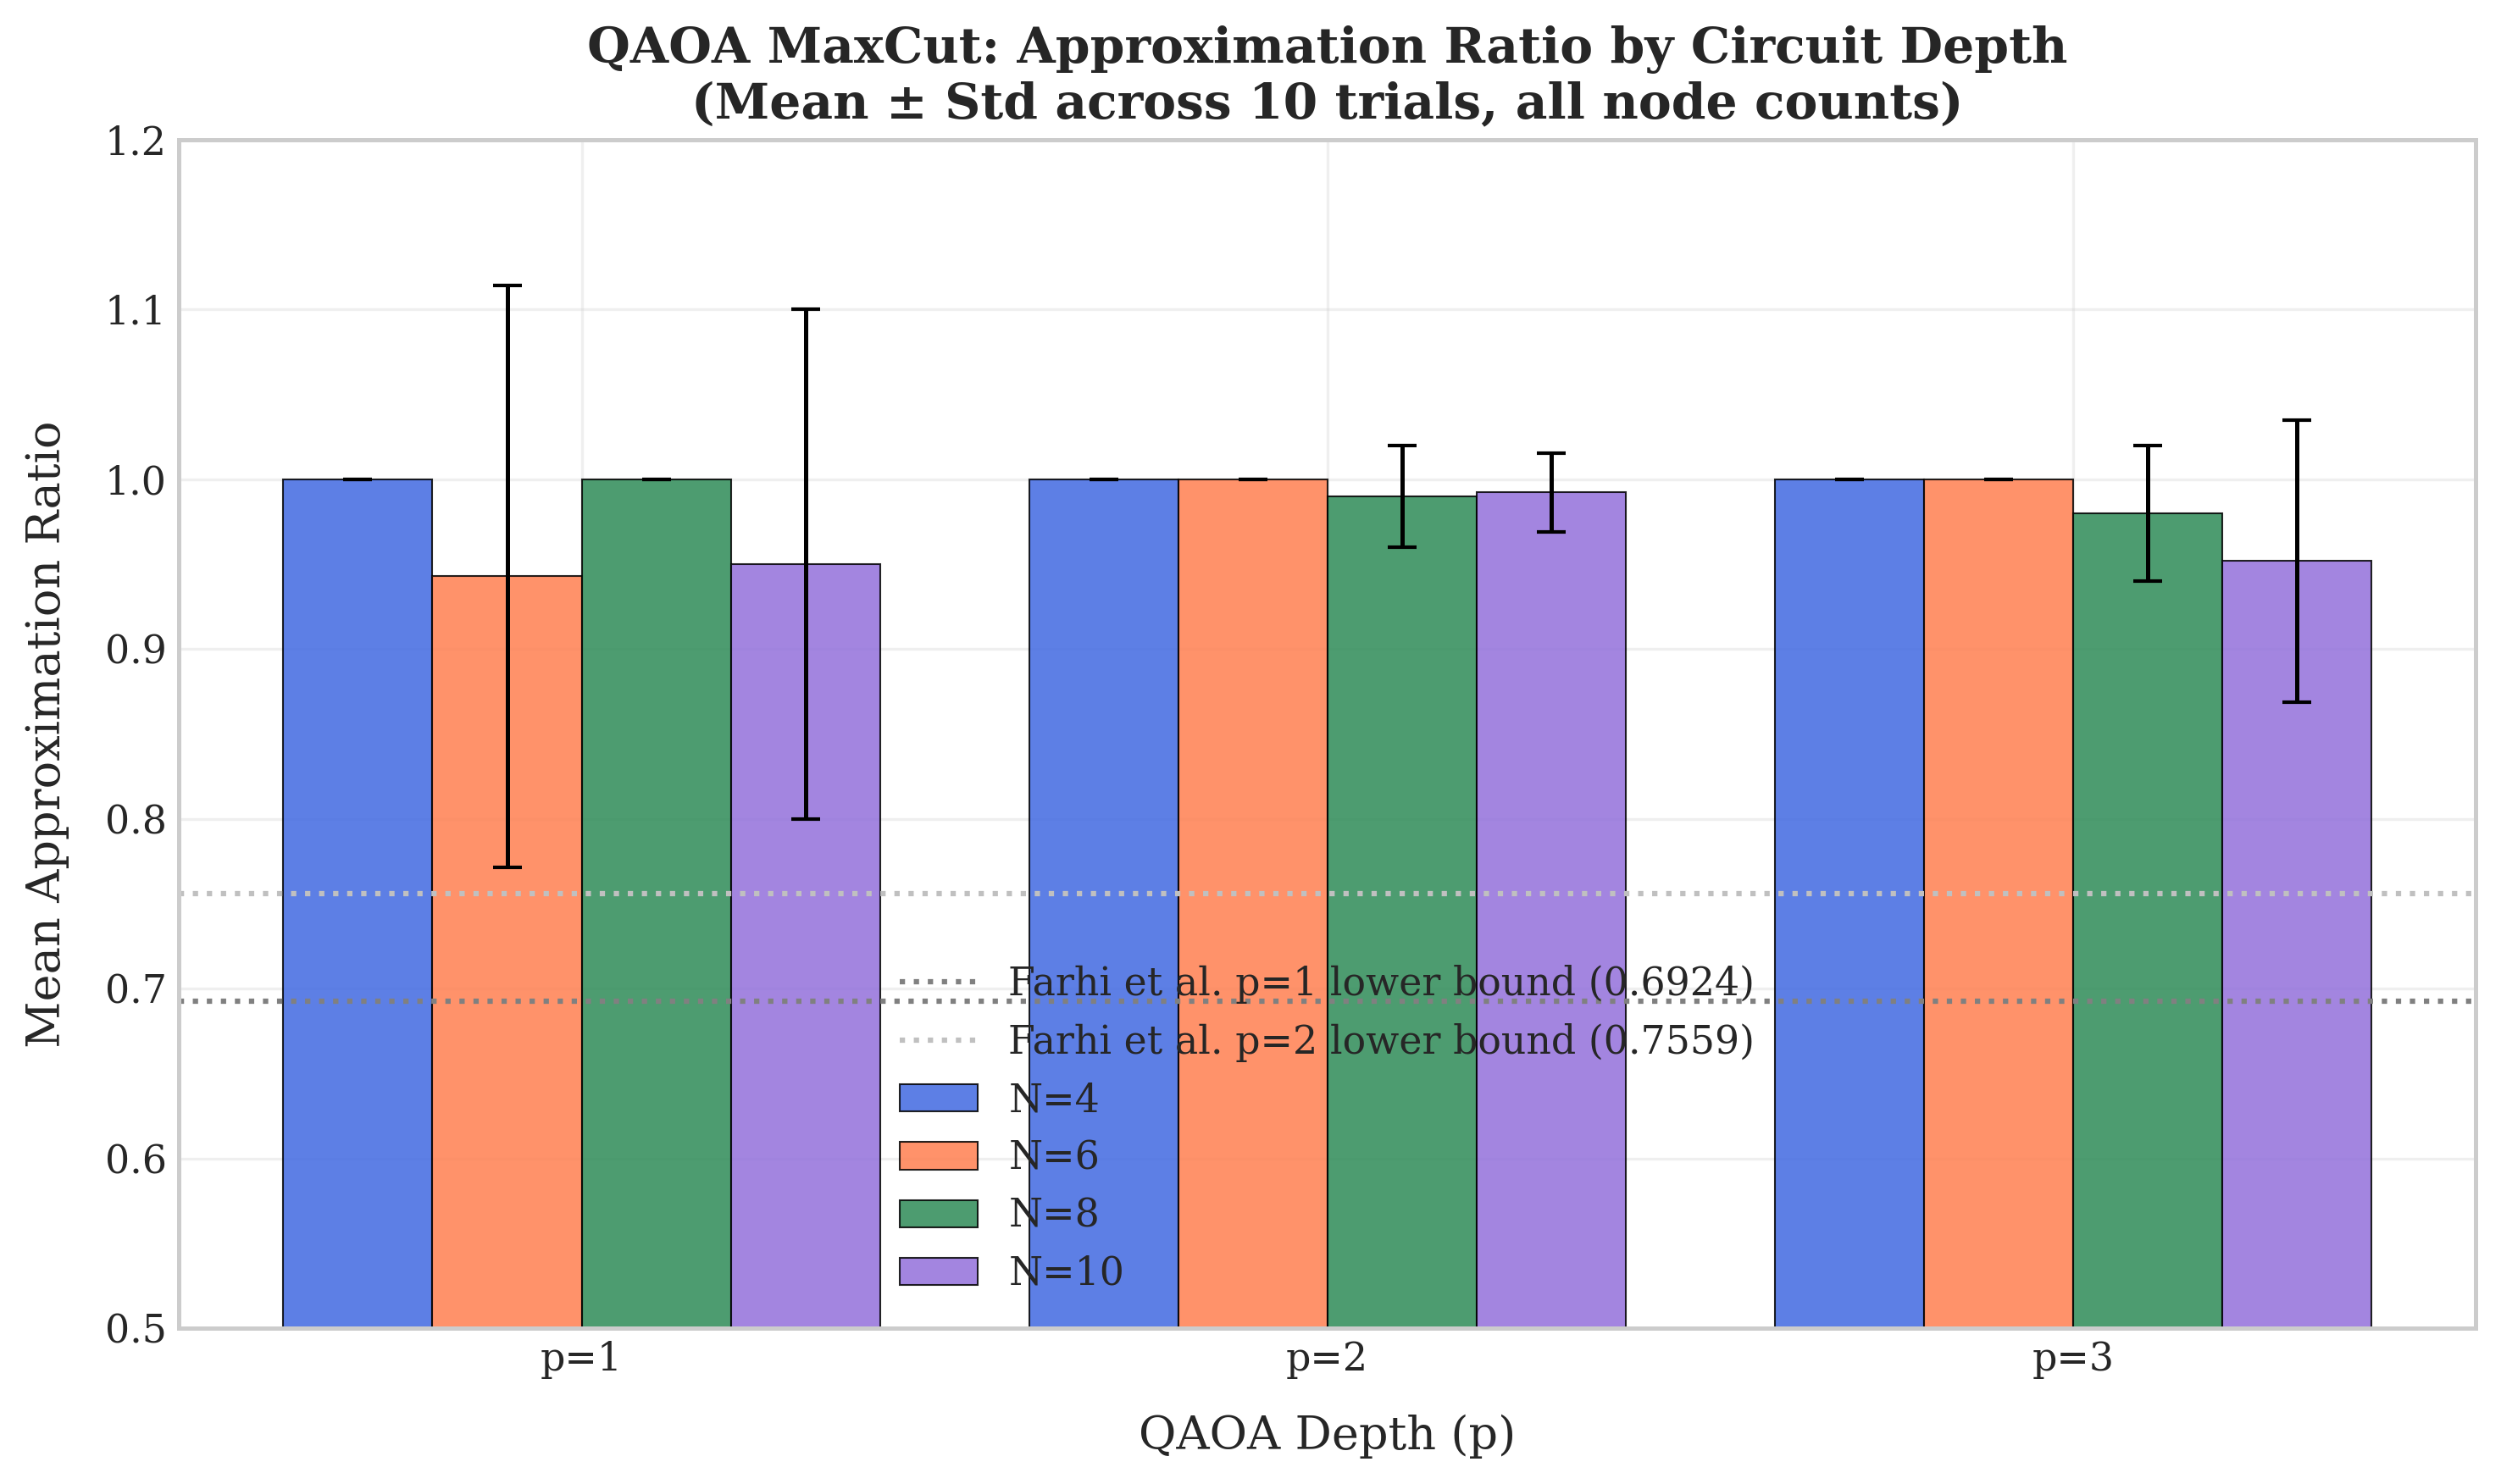

Plot 3.2 saved!


In [11]:
# ── Plot 3.2: AR by QAOA Depth ───────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(P_VALUES))
width = 0.2
node_colors = ['royalblue', 'coral', 'seagreen', 'mediumpurple']

for idx, N in enumerate(NODE_COUNTS):
    n_results = [r for r in qaoa_results if r['N'] == N]
    mean_ar = [r['mean_approx_ratio'] for r in n_results]
    std_ar = [r['std'] for r in n_results]

    bars = ax.bar(x + (idx - 1.5) * width, mean_ar, width,
                  label=f'N={N}', color=node_colors[idx],
                  alpha=0.85, edgecolor='black', linewidth=0.5)
    ax.errorbar(x + (idx - 1.5) * width, mean_ar, yerr=std_ar,
                fmt='none', color='black', capsize=4, linewidth=1.2)

ax.axhline(y=0.6924, color='gray', linestyle=':',
           linewidth=1.5, label='Farhi et al. p=1 lower bound (0.6924)')
ax.axhline(y=0.7559, color='silver', linestyle=':',
           linewidth=1.5, label='Farhi et al. p=2 lower bound (0.7559)')
ax.set_xlabel('QAOA Depth (p)', labelpad=10)
ax.set_ylabel('Mean Approximation Ratio', labelpad=10)
ax.set_title('QAOA MaxCut: Approximation Ratio by Circuit Depth\n'
             '(Mean ± Std across 10 trials, all node counts)',
             fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([f'p={p}' for p in P_VALUES])
ax.set_ylim(0.5, 1.2)
ax.legend(framealpha=0.9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('qaoa_comparison_ar_by_depth.png', dpi=300, bbox_inches='tight')
plt.show()
print("Plot 3.2 saved!")

## 4. Runtime Comparison

Comparing wall-clock runtime between QAOA and Simulated Annealing across
all configurations.

**Timing method:**
- Quantum: client-side wall-clock timing (time.time())
- Classical: time.perf_counter()

**Reference:** Lubinski et al. (2023, IEEE Transactions on Quantum Engineering,
DOI: 10.1109/TQE.2023.3253761) — QED-C benchmark uses wall-clock runtime
as primary timing metric for quantum vs classical comparison. Proctor et al.
(2022, Nature Physics, DOI: 10.1038/s41567-021-01409-7) — runtime measurement
methodology for quantum benchmarking.

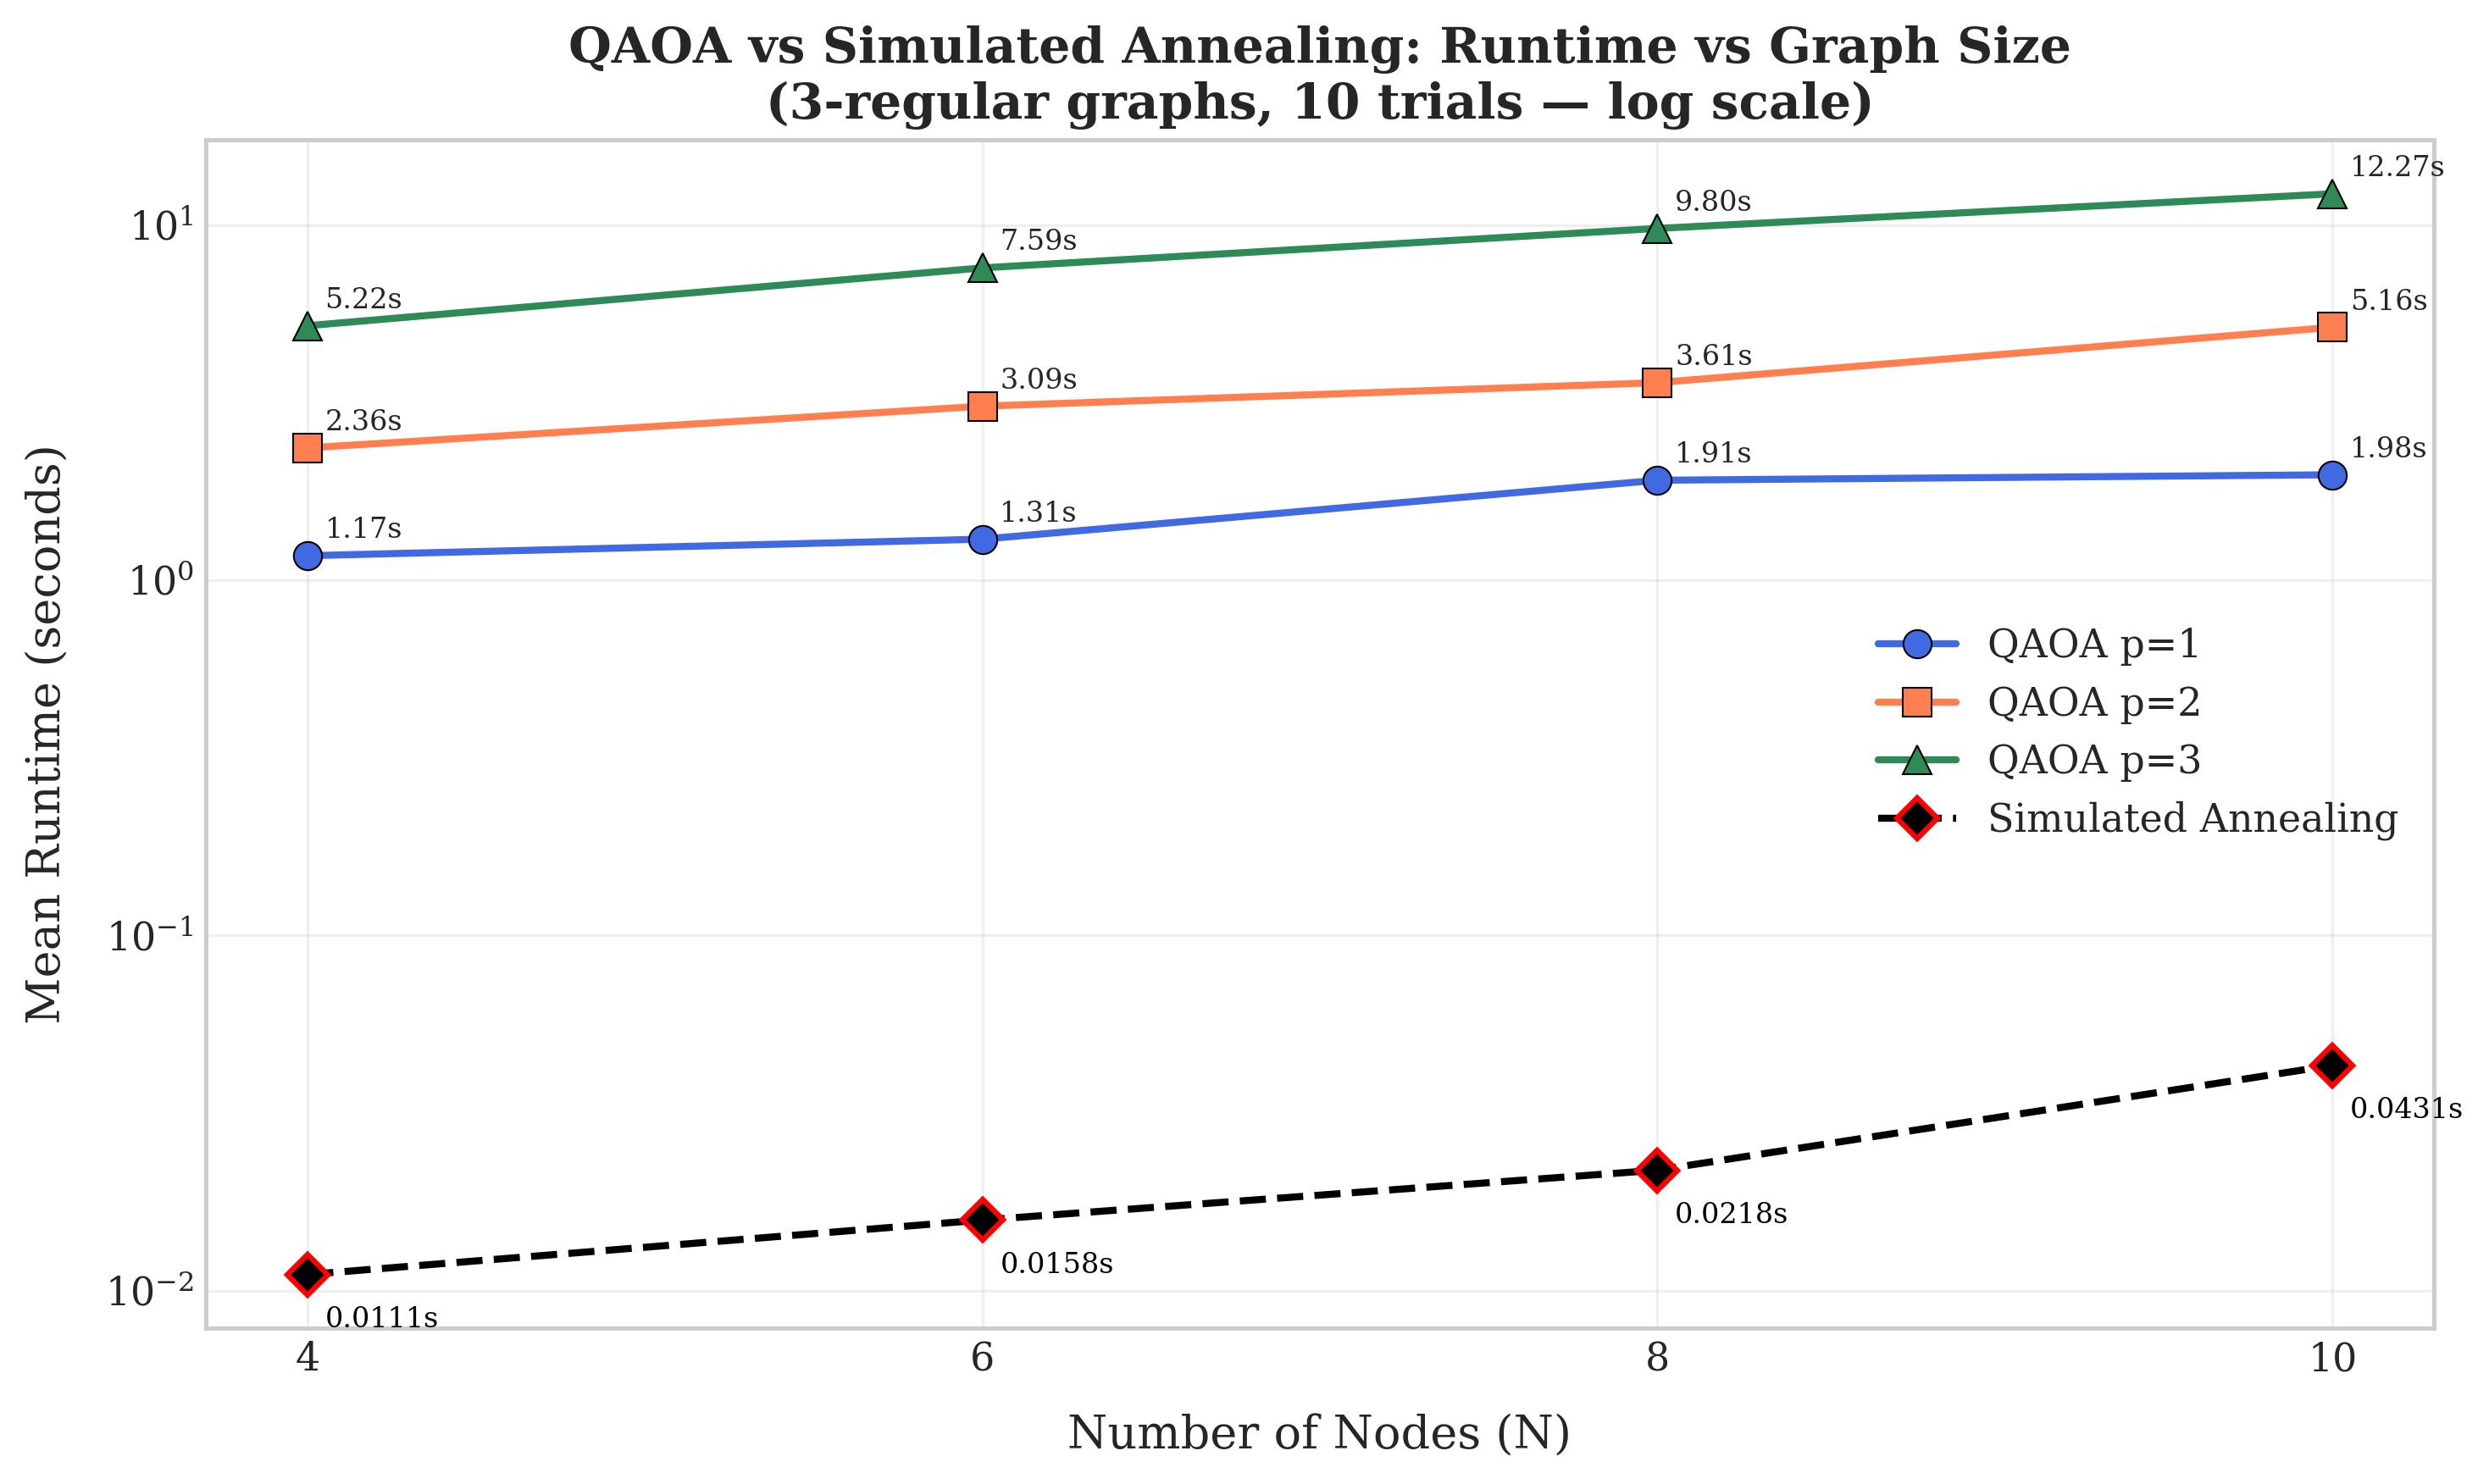

Runtime plot saved!


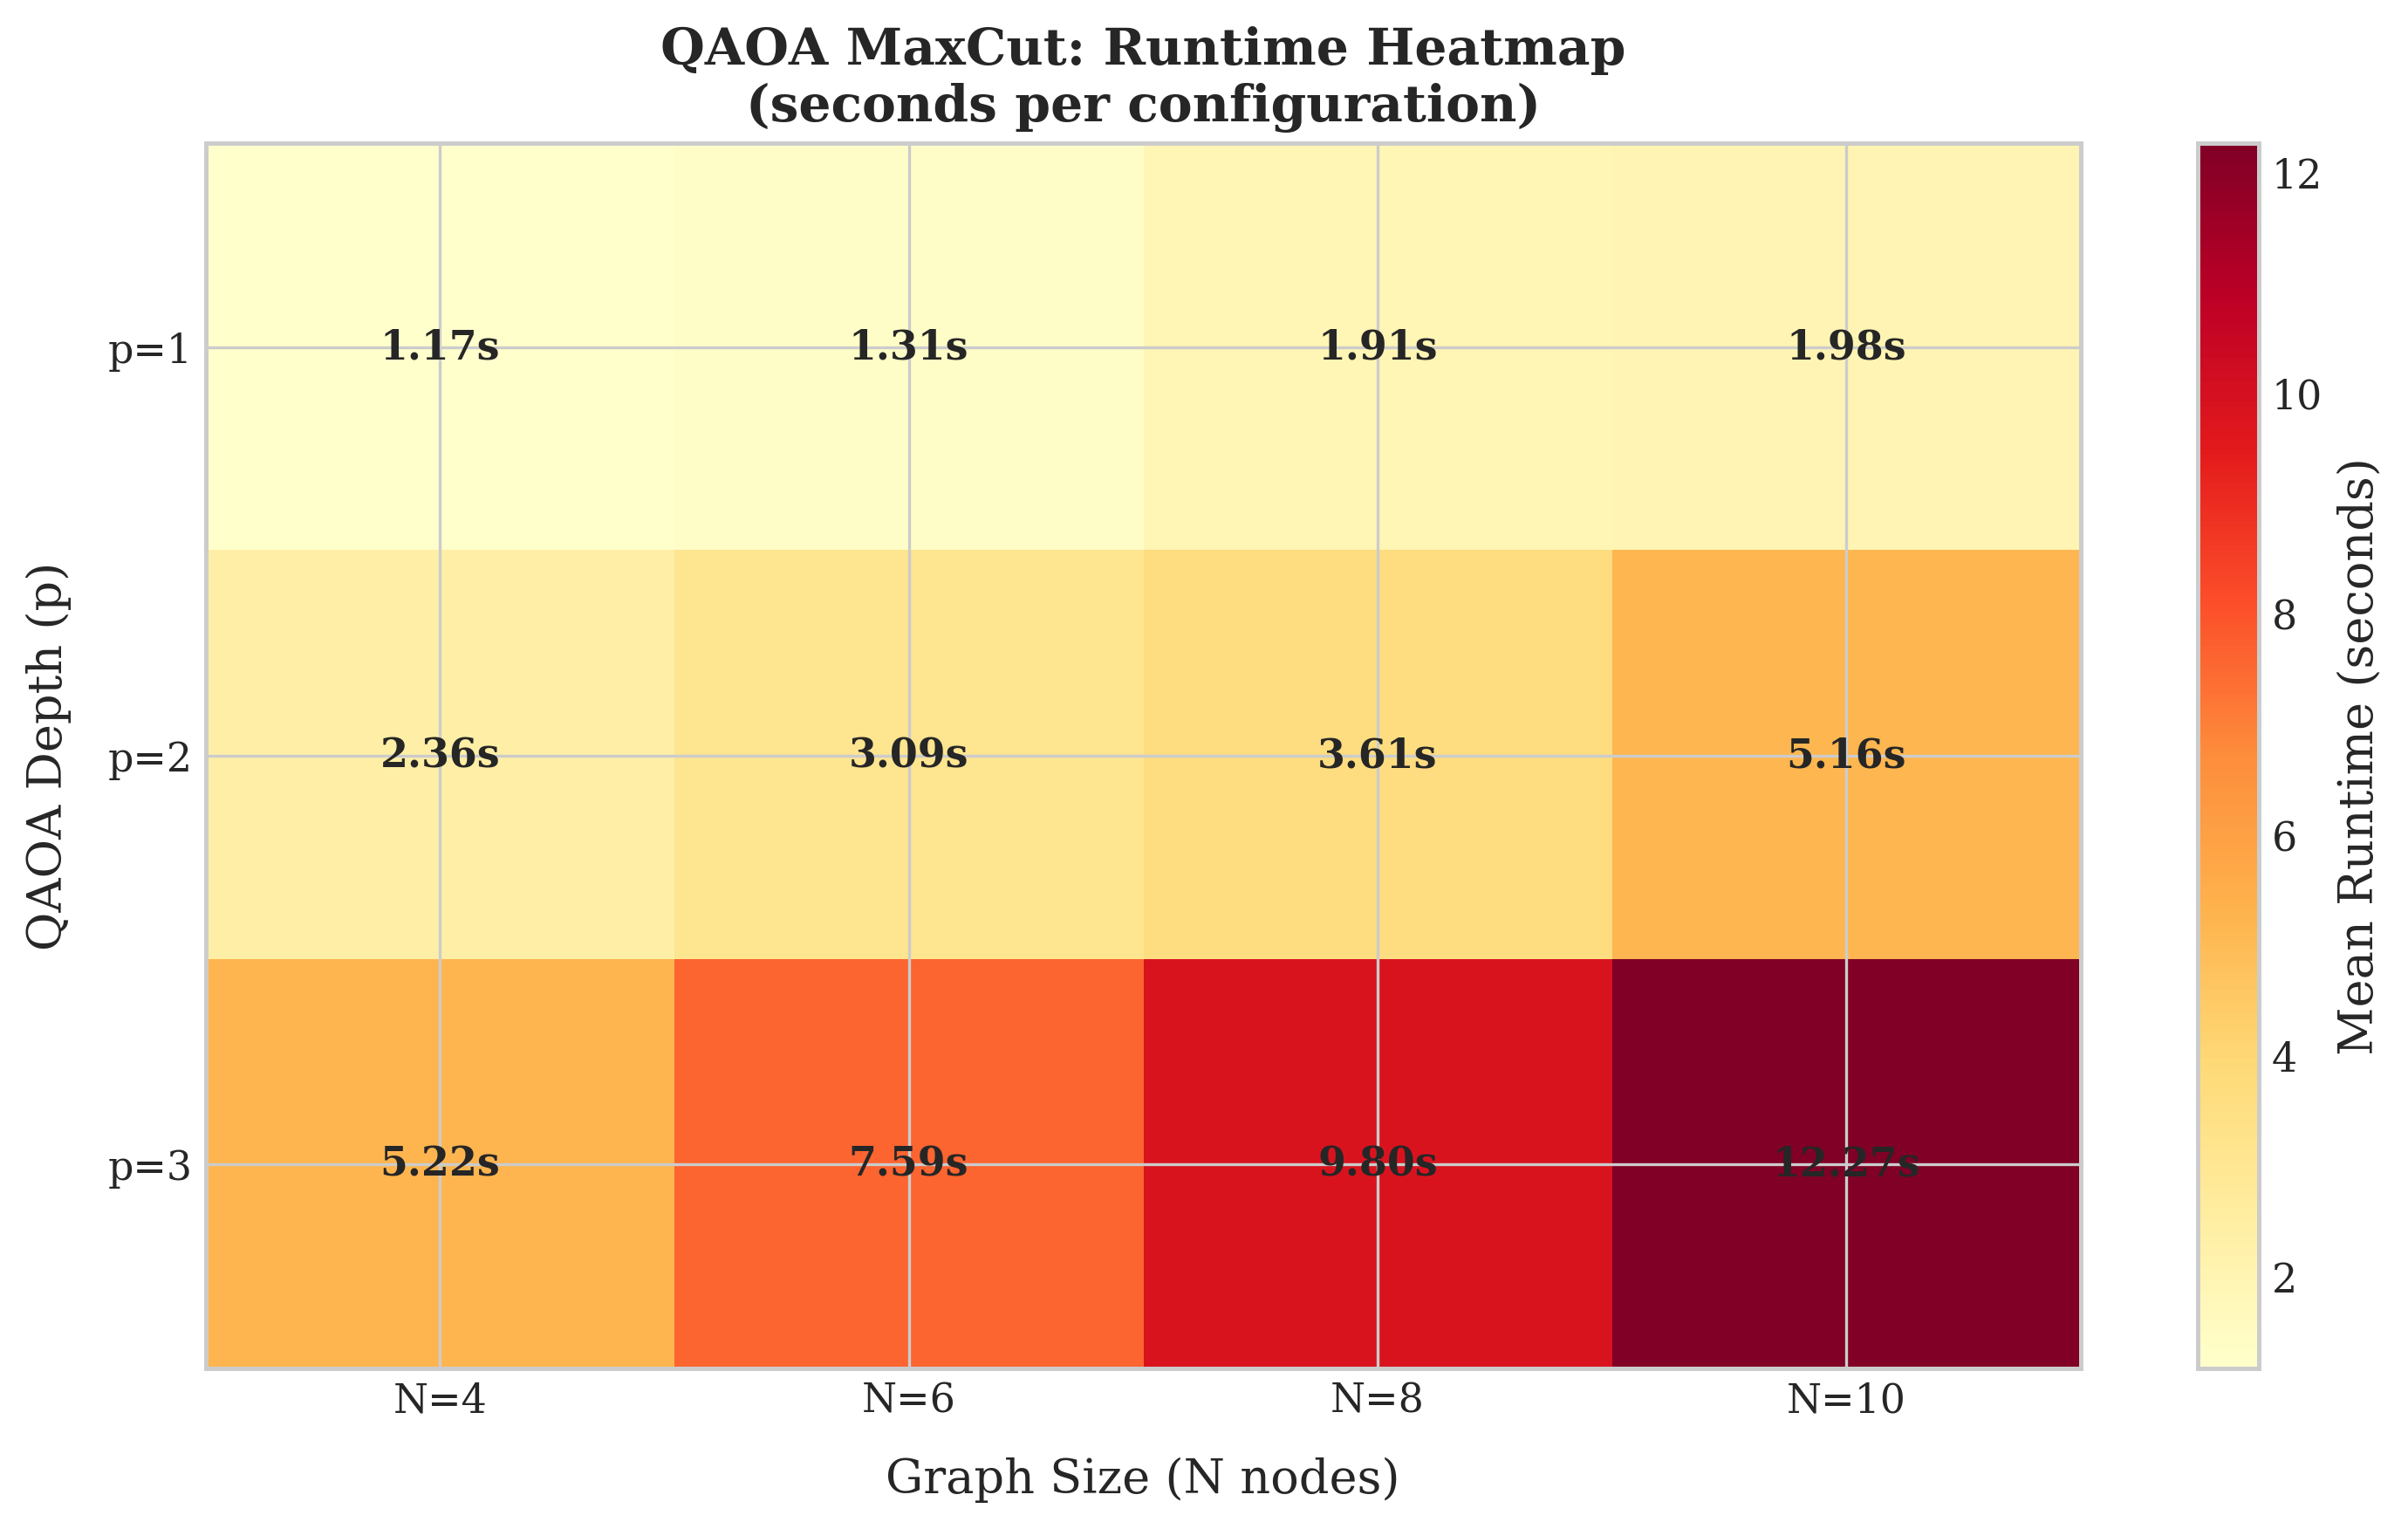

Runtime heatmap saved!


In [12]:
# ── Plot 4.1: Runtime by Node Count (QAOA vs SA) ─────────
fig, ax = plt.subplots(figsize=(10, 6))

for p in P_VALUES:
    p_results = [r for r in qaoa_results if r['p'] == p]
    nodes = [r['N'] for r in p_results]
    runtimes = [r['mean_runtime'] for r in p_results]

    ax.plot(nodes, runtimes, f'{markers_p[p]}-',
            color=colors_p[p], linewidth=2, markersize=8,
            markeredgecolor='black', markeredgewidth=0.5,
            label=f'QAOA p={p}')
    for n, rt in zip(nodes, runtimes):
        ax.annotate(f'{rt:.2f}s', (n, rt),
                    textcoords='offset points',
                    xytext=(5, 5), fontsize=8)

# SA runtime — now available!
sa_rts = [r['mean_runtime'] for r in sa_results]
ax.plot(NODE_COUNTS, sa_rts, 'D--', color='black',
        linewidth=2, markersize=8,
        markeredgecolor='red', markeredgewidth=1.5,
        label='Simulated Annealing')
for n, rt in zip(NODE_COUNTS, sa_rts):
    ax.annotate(f'{rt:.4f}s', (n, rt),
                textcoords='offset points',
                xytext=(5, -15), fontsize=8, color='black')

ax.set_xlabel('Number of Nodes (N)', labelpad=10)
ax.set_ylabel('Mean Runtime (seconds)', labelpad=10)
ax.set_title('QAOA vs Simulated Annealing: Runtime vs Graph Size\n'
             '(3-regular graphs, 10 trials — log scale)',
             fontweight='bold')
ax.set_xticks(NODE_COUNTS)
ax.set_yscale('log')  # log scale shows SA vs QAOA difference clearly
ax.legend(framealpha=0.9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('qaoa_comparison_runtime.png', dpi=300, bbox_inches='tight')
plt.show()
print("Runtime plot saved!")

# ── Plot 4.2: Runtime Heatmap ─────────────────────────────
runtime_matrix = np.zeros((len(P_VALUES), len(NODE_COUNTS)))
for r in qaoa_results:
    i = P_VALUES.index(r['p'])
    j = NODE_COUNTS.index(r['N'])
    runtime_matrix[i, j] = r['mean_runtime']

fig, ax = plt.subplots(figsize=(10, 6))
im = ax.imshow(runtime_matrix, cmap='YlOrRd', aspect='auto')
plt.colorbar(im, ax=ax, label='Mean Runtime (seconds)')
for i in range(len(P_VALUES)):
    for j in range(len(NODE_COUNTS)):
        ax.text(j, i, f'{runtime_matrix[i,j]:.2f}s',
                ha='center', va='center',
                fontsize=11, fontweight='bold')
ax.set_xticks(range(len(NODE_COUNTS)))
ax.set_xticklabels([f'N={n}' for n in NODE_COUNTS])
ax.set_yticks(range(len(P_VALUES)))
ax.set_yticklabels([f'p={p}' for p in P_VALUES])
ax.set_xlabel('Graph Size (N nodes)', labelpad=10)
ax.set_ylabel('QAOA Depth (p)', labelpad=10)
ax.set_title('QAOA MaxCut: Runtime Heatmap\n'
             '(seconds per configuration)',
             fontweight='bold')
plt.tight_layout()
plt.savefig('qaoa_comparison_runtime_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()
print("Runtime heatmap saved!")

## 5. Statistical Tests

### 5.1 t-test: Approximation Ratios

Testing whether the difference in approximation ratios between QAOA and
Simulated Annealing is statistically significant.

**Test used:** Independent samples t-test (scipy.stats.ttest_ind)  
**Null hypothesis (H₀):** Mean AR of QAOA = Mean AR of Simulated Annealing  
**Alternative hypothesis (H₁):** Mean AR values are significantly different  
**Significance level:** α = 0.05  
**Interpretation:** p < 0.05 → reject H₀ → statistically significant difference

**Reference:** Willsch et al. (2020, Quantum Information Processing) use
mean and variance of approximation ratio across multiple trials for
statistical comparison of QAOA performance. Independent t-test is the
standard parametric test for comparing two independent sample means
(Montgomery and Runger, Applied Statistics and Probability for Engineers).

In [13]:
# ── Statistical Tests: AR ─────────────────────────────────
# Uses real per-trial QAOA data (qaoa_experiment_004.json, 120 trials),
# not p-level aggregation or fabricated SA padding.

qaoa_ar_all_trials = qaoa_pertrial_df['approx_ratio'].values  # 120 real trials
sa_ar_all = [r['mean_approx_ratio'] for r in sa_results]      # 4 real values, one per N

print("=" * 60)
print("Statistical Analysis: QAOA vs SA Approximation Ratios")
print("=" * 60)

print(f"\nQAOA Summary (all 120 real per-trial values):")
print(f"  Mean AR:  {qaoa_ar_all_trials.mean():.4f}")
print(f"  Std AR:   {qaoa_ar_all_trials.std(ddof=1):.4f}")
print(f"  Min AR:   {qaoa_ar_all_trials.min():.4f}")
print(f"  Max AR:   {qaoa_ar_all_trials.max():.4f}")

print(f"\nSA Summary:")
print(f"  Mean AR:  {np.mean(sa_ar_all):.4f}")
print(f"  Std AR:   {np.std(sa_ar_all):.4f}")
print(f"  Min AR:   {min(sa_ar_all):.4f}")
print(f"  Max AR:   {max(sa_ar_all):.4f}")

# QAOA vs Farhi et al. lower bound -- single-sample test against a fixed
# theoretical constant, not against SA, so this was always valid; now uses
# all 120 real trials instead of 12 p-level means.
print(f"\nQAOA vs Farhi et al. lower bound (0.6924):")
t_stat, p_value = stats.ttest_1samp(qaoa_ar_all_trials, 0.6924)
print(f"  t-statistic: {t_stat:.4f}")
print(f"  p-value:     {p_value:.6f}")
print(f"  Result: {'Significantly above lower bound' if p_value < 0.05 else 'Not significant'}")

# By p value -- now real per-trial std, not std-across-N
print(f"\nAR by QAOA depth (real per-trial std):")
for p in P_VALUES:
    p_trials = qaoa_pertrial_df[qaoa_pertrial_df['p'] == p]['approx_ratio']
    print(f"  p={p}: Mean={p_trials.mean():.4f} | Std={p_trials.std(ddof=1):.4f} | n={len(p_trials)}")

# By node count -- QAOA best p vs SA
print(f"\nAR by node count (QAOA best p vs SA):")
for N in NODE_COUNTS:
    qaoa_best = qaoa_pertrial_df[qaoa_pertrial_df['N'] == N].groupby('p')['approx_ratio'].mean().max()
    sa_ar = next(r['mean_approx_ratio'] for r in sa_results if r['N'] == N)
    winner = 'QAOA' if qaoa_best > sa_ar else ('SA' if sa_ar > qaoa_best else 'TIE')
    print(f"  N={N:2d}: QAOA={qaoa_best:.4f} | SA={sa_ar:.4f} | {winner}")

print("=" * 60)

# ── Per-N Welch's t-test: QAOA (best-p, real trials) vs SA ──
print(f"\nPer-N Welch's t-test (QAOA best-p real trials vs SA):")
print("Note: SA has zero variance at every N (always finds optimal cut).")
print("      When QAOA also has zero variance at a given N (a real ceiling")
print("      effect, not missing data), the comparison is deterministic-vs-")
print("      deterministic and no significance test applies.")
print("-" * 60)

sa_std_by_N = {r['N']: 0.0 for r in sa_results}  # SA std is genuinely 0 everywhere
sa_ar_by_N = {r['N']: r['mean_approx_ratio'] for r in sa_results}

for N in NODE_COUNTS:
    best_p = qaoa_pertrial_df[qaoa_pertrial_df['N']==N].groupby('p')['approx_ratio'].mean().idxmax()
    qaoa_trials = qaoa_pertrial_df[(qaoa_pertrial_df['N']==N) & (qaoa_pertrial_df['p']==best_p)]['approx_ratio'].values
    qaoa_std = qaoa_trials.std(ddof=1)

    if qaoa_std == 0 and sa_std_by_N[N] == 0:
        print(f"  N={N:2d} (best p={best_p}) | QAOA={qaoa_trials.mean():.4f} (std=0) | "
              f"SA={sa_ar_by_N[N]:.4f} (std=0) | both deterministic — no test applicable")
        continue

    t_stat, p_val = stats.ttest_ind_from_stats(
        mean1=qaoa_trials.mean(), std1=qaoa_std, nobs1=len(qaoa_trials),
        mean2=sa_ar_by_N[N], std2=max(sa_std_by_N[N], 1e-6), nobs2=10,
        equal_var=False)
    result = 'Significant' if p_val < 0.05 else 'Not significant'
    print(f"  N={N:2d} (best p={best_p}) | t={t_stat:.4f} | p={p_val:.4f} | {result}")

print("=" * 60)

Statistical Analysis: QAOA vs SA Approximation Ratios

QAOA Summary (all 120 real per-trial values):
  Mean AR:  0.9839
  Std AR:   0.0752
  Min AR:   0.4286
  Max AR:   1.0000

SA Summary:
  Mean AR:  1.0000
  Std AR:   0.0000
  Min AR:   1.0000
  Max AR:   1.0000

QAOA vs Farhi et al. lower bound (0.6924):
  t-statistic: 42.4503
  p-value:     0.000000
  Result: Significantly above lower bound

AR by QAOA depth (real per-trial std):
  p=1: Mean=0.9732 | Std=0.1185 | n=40
  p=2: Mean=0.9956 | Std=0.0197 | n=40
  p=3: Mean=0.9830 | Std=0.0508 | n=40

AR by node count (QAOA best p vs SA):
  N= 4: QAOA=1.0000 | SA=1.0000 | TIE
  N= 6: QAOA=1.0000 | SA=1.0000 | TIE
  N= 8: QAOA=1.0000 | SA=1.0000 | TIE
  N=10: QAOA=0.9923 | SA=1.0000 | SA

Per-N Welch's t-test (QAOA best-p real trials vs SA):
Note: SA has zero variance at every N (always finds optimal cut).
      When QAOA also has zero variance at a given N (a real ceiling
      effect, not missing data), the comparison is deterministic-

### 5.2 t-test: Runtimes

Testing whether the runtime difference between QAOA and Simulated
Annealing is statistically significant.

**Test used:** Independent samples t-test (scipy.stats.ttest_ind)  
**Null hypothesis (H₀):** Mean runtime of QAOA = Mean runtime of SA  
**Alternative hypothesis (H₁):** Runtimes are significantly different  
**Significance level:** α = 0.05

**Reference:** Lubinski et al. (2023, IEEE Transactions on Quantum Engineering)
— QED-C framework uses statistical comparison of runtimes across multiple
trials as a standard quantum benchmarking practice. Tomesh et al. (2022,
IEEE HPCA — SupermarQ) use runtime distributions for hardware-agnostic
quantum benchmarking comparison.

In [15]:
# ── Statistical Tests: Runtime ────────────────────────────
# QAOA side uses real per-trial runtime (qaoa_experiment_004.json).
# SA side uses its own real aggregate std (10 real trials per Kanishka's protocol).

print("=" * 60)
print("Statistical Analysis: QAOA vs SA Runtimes")
print("=" * 60)

qaoa_rt_all_trials = qaoa_pertrial_df['runtime_seconds'].values
sa_rt_all = [r['mean_runtime'] for r in sa_results]

print(f"\nQAOA Runtime Summary (all 120 real trials):")
print(f"  Mean: {qaoa_rt_all_trials.mean():.4f}s")
print(f"  Std:  {qaoa_rt_all_trials.std(ddof=1):.4f}s")
print(f"  Min:  {qaoa_rt_all_trials.min():.4f}s")
print(f"  Max:  {qaoa_rt_all_trials.max():.4f}s")

print(f"\nSA Runtime Summary:")
print(f"  Mean: {np.mean(sa_rt_all):.5f}s")
print(f"  Std:  {np.std(sa_rt_all):.5f}s")
print(f"  Min:  {min(sa_rt_all):.5f}s")
print(f"  Max:  {max(sa_rt_all):.5f}s")

# Per-N runtime t-test at p=1 (matching the Speedup section's convention),
# using real QAOA trial variance vs SA's real 10-trial aggregate std/nobs.
print(f"\nPer-N Welch's t-test: QAOA (p=1, real trials) vs SA runtime:")
print("-" * 60)
for N in NODE_COUNTS:
    qaoa_trials = qaoa_pertrial_df[(qaoa_pertrial_df['N']==N) & (qaoa_pertrial_df['p']==1)]['runtime_seconds'].values
    sa_r = next(r for r in sa_results if r['N'] == N)
    t_stat, p_val = stats.ttest_ind_from_stats(
        mean1=qaoa_trials.mean(), std1=qaoa_trials.std(ddof=1), nobs1=len(qaoa_trials),
        mean2=sa_r['mean_runtime'], std2=max(sa_r['std_runtime'], 1e-6), nobs2=10,
        equal_var=False)
    result = 'Significant' if p_val < 0.05 else 'Not significant'
    print(f"  N={N:2d} | QAOA={qaoa_trials.mean():.4f}s | SA={sa_r['mean_runtime']:.5f}s | "
          f"t={t_stat:.4f} | p={p_val:.6f} | {result}")

# Speedup factor -- unchanged, already valid (ratio only, no variance claim)
print(f"\nSpeedup: SA vs QAOA (p=1):")
for N in NODE_COUNTS:
    qaoa_rt = qaoa_pertrial_df[(qaoa_pertrial_df['N']==N) & (qaoa_pertrial_df['p']==1)]['runtime_seconds'].mean()
    sa_rt = next(r['mean_runtime'] for r in sa_results if r['N'] == N)
    speedup = qaoa_rt / sa_rt
    print(f"  N={N:2d}: QAOA={qaoa_rt:.4f}s | SA={sa_rt:.5f}s | SA is {speedup:.0f}x faster")

# Runtime by p value -- now real per-trial std
print(f"\nRuntime by QAOA depth (real per-trial std):")
for p in P_VALUES:
    p_rt = qaoa_pertrial_df[qaoa_pertrial_df['p'] == p]['runtime_seconds']
    print(f"  p={p}: Mean={p_rt.mean():.4f}s | Std={p_rt.std(ddof=1):.4f}s | n={len(p_rt)}")

# Correlation -- unchanged, this level (one point per N) was already correct
print(f"\nCorrelation: Runtime vs Node Count (p=1):")
p1_nodes = [r['N'] for r in qaoa_results if r['p'] == 1]
p1_rts = [r['mean_runtime'] for r in qaoa_results if r['p'] == 1]
correlation, corr_pval = stats.pearsonr(p1_nodes, p1_rts)
print(f"  Pearson r = {correlation:.4f} | p-value = {corr_pval:.4f}")
if correlation > 0.7 and corr_pval < 0.05:
    verdict = "Strong positive correlation, statistically significant"
elif correlation > 0.7:
    verdict = "Strong positive correlation, but p-value is marginal (n=4, low power)"
else:
    verdict = "Weak correlation"
print(f"  Result: {verdict}")
print("=" * 60)

Statistical Analysis: QAOA vs SA Runtimes

QAOA Runtime Summary (all 120 real trials):
  Mean: 4.6231s
  Std:  3.5818s
  Min:  0.7284s
  Max:  16.4377s

SA Runtime Summary:
  Mean: 0.02295s
  Std:  0.01223s
  Min:  0.01110s
  Max:  0.04308s

Per-N Welch's t-test: QAOA (p=1, real trials) vs SA runtime:
------------------------------------------------------------
  N= 4 | QAOA=1.1737s | SA=0.01110s | t=4.4318 | p=0.001643 | Significant
  N= 6 | QAOA=1.3066s | SA=0.01580s | t=13.0844 | p=0.000000 | Significant
  N= 8 | QAOA=1.9147s | SA=0.02183s | t=8.9800 | p=0.000009 | Significant
  N=10 | QAOA=1.9839s | SA=0.04308s | t=24.5833 | p=0.000000 | Significant

Speedup: SA vs QAOA (p=1):
  N= 4: QAOA=1.1737s | SA=0.01110s | SA is 106x faster
  N= 6: QAOA=1.3066s | SA=0.01580s | SA is 83x faster
  N= 8: QAOA=1.9147s | SA=0.02183s | SA is 88x faster
  N=10: QAOA=1.9839s | SA=0.04308s | SA is 46x faster

Runtime by QAOA depth (real per-trial std):
  p=1: Mean=1.5947s | Std=0.6558s | n=40
  p=2: 

### Joselyn-Approved Unique Comparison Plots

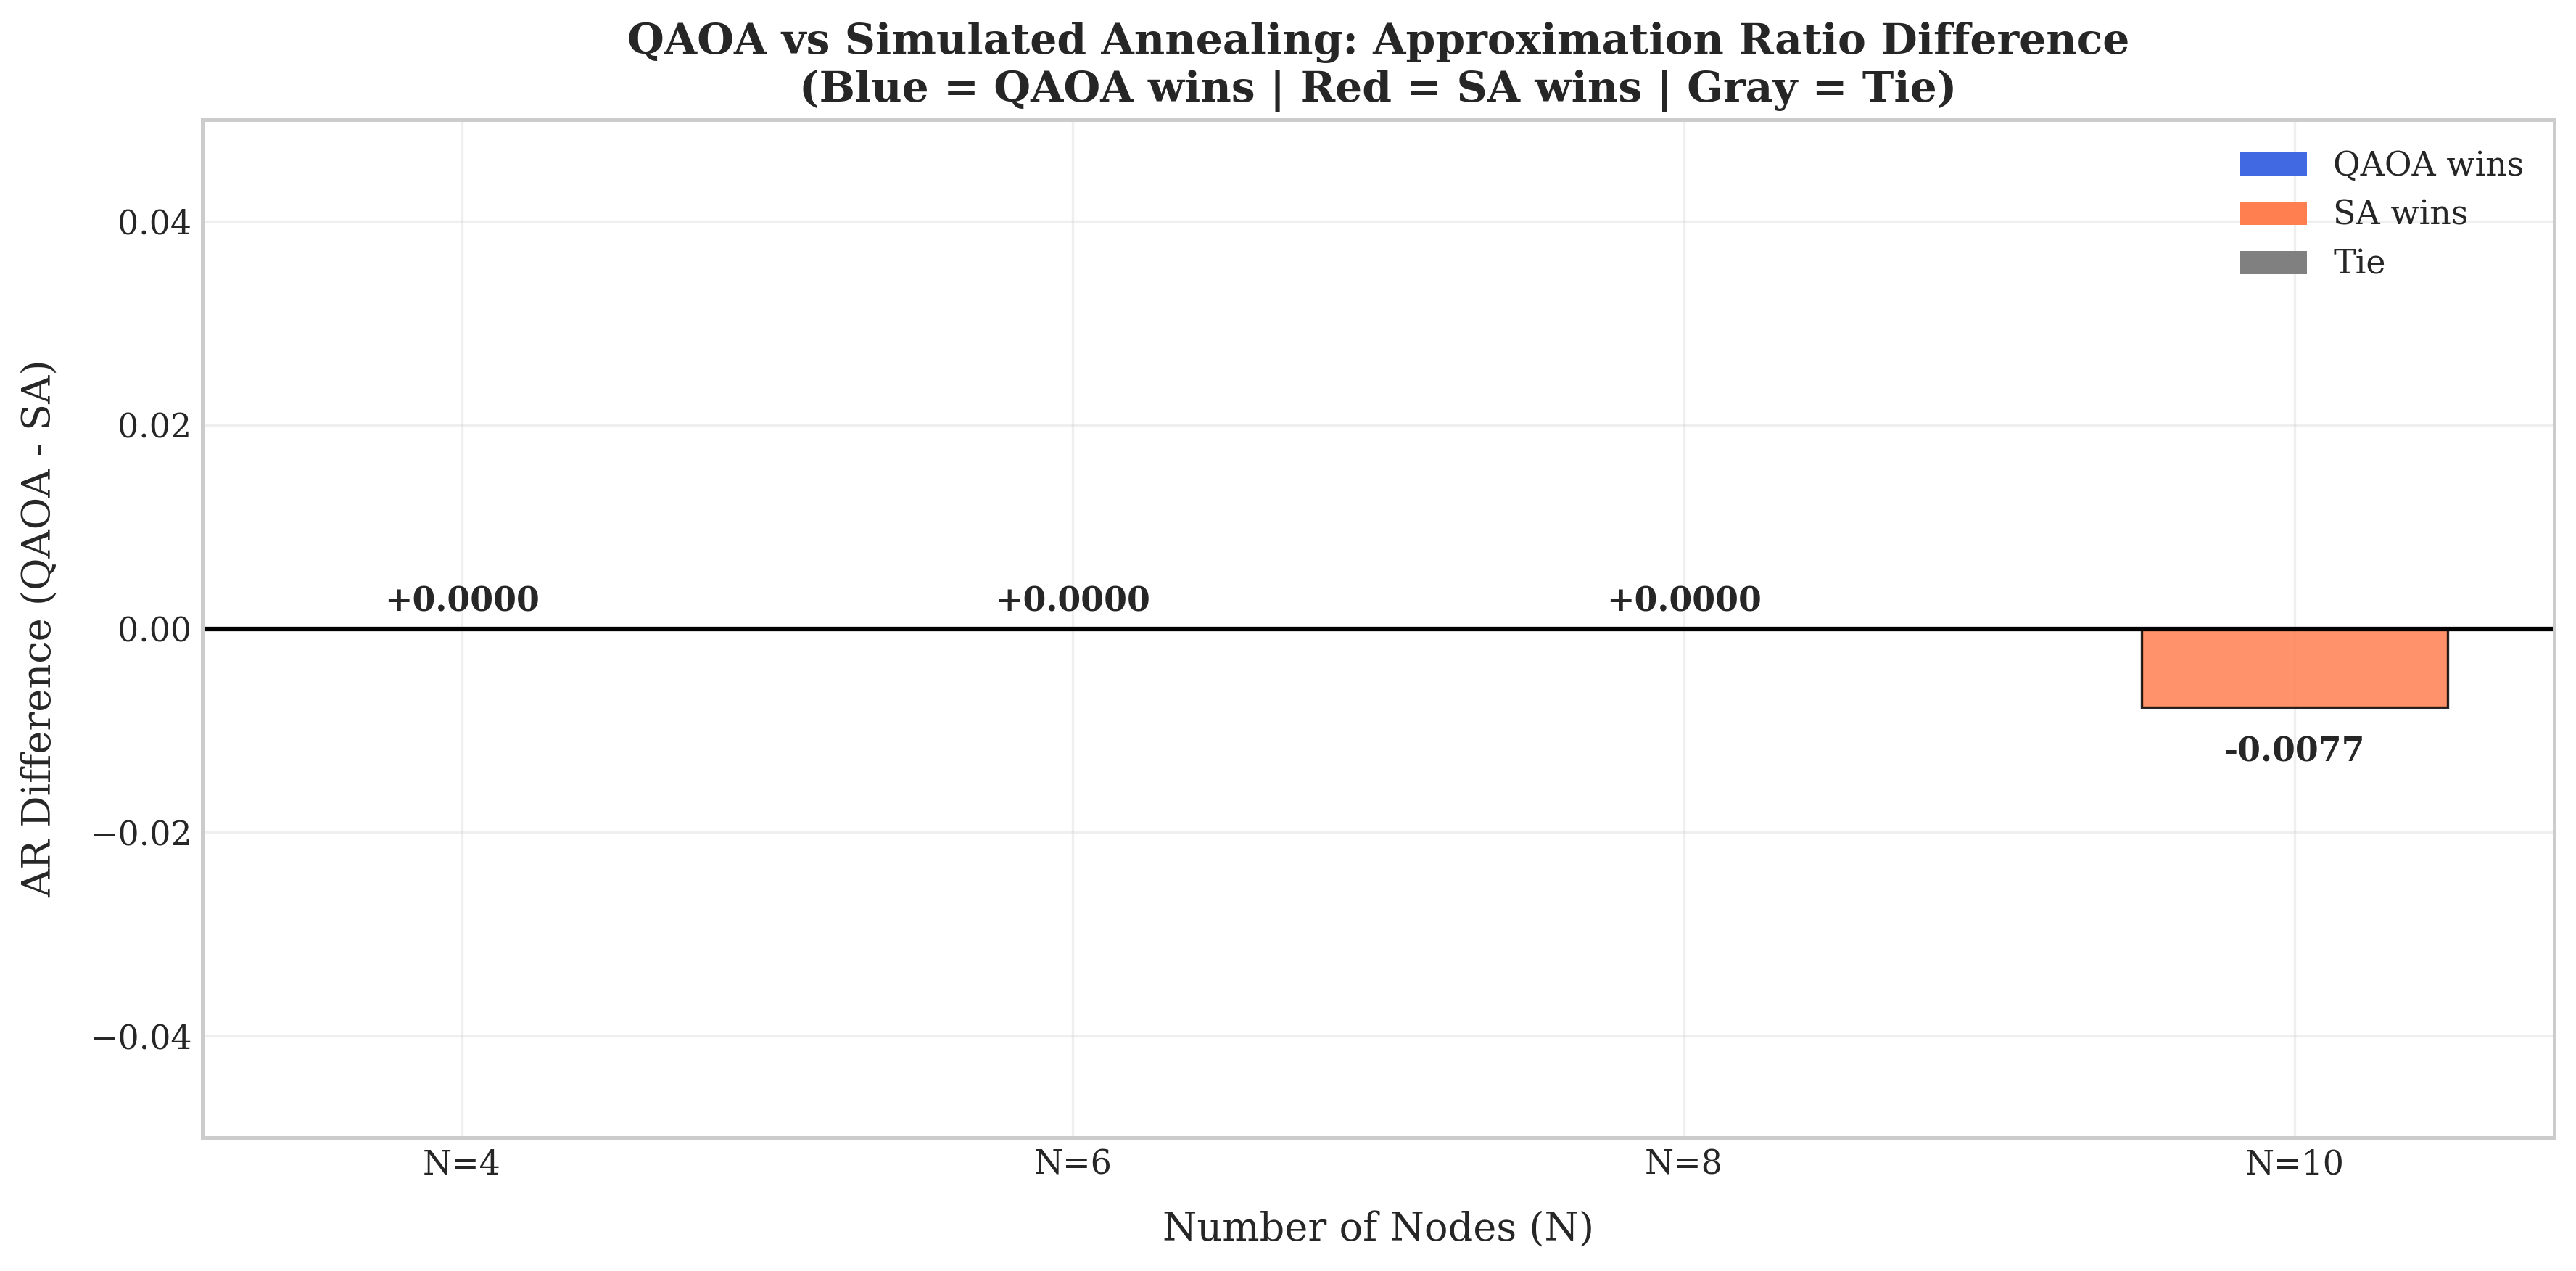

Diverging bar chart saved!


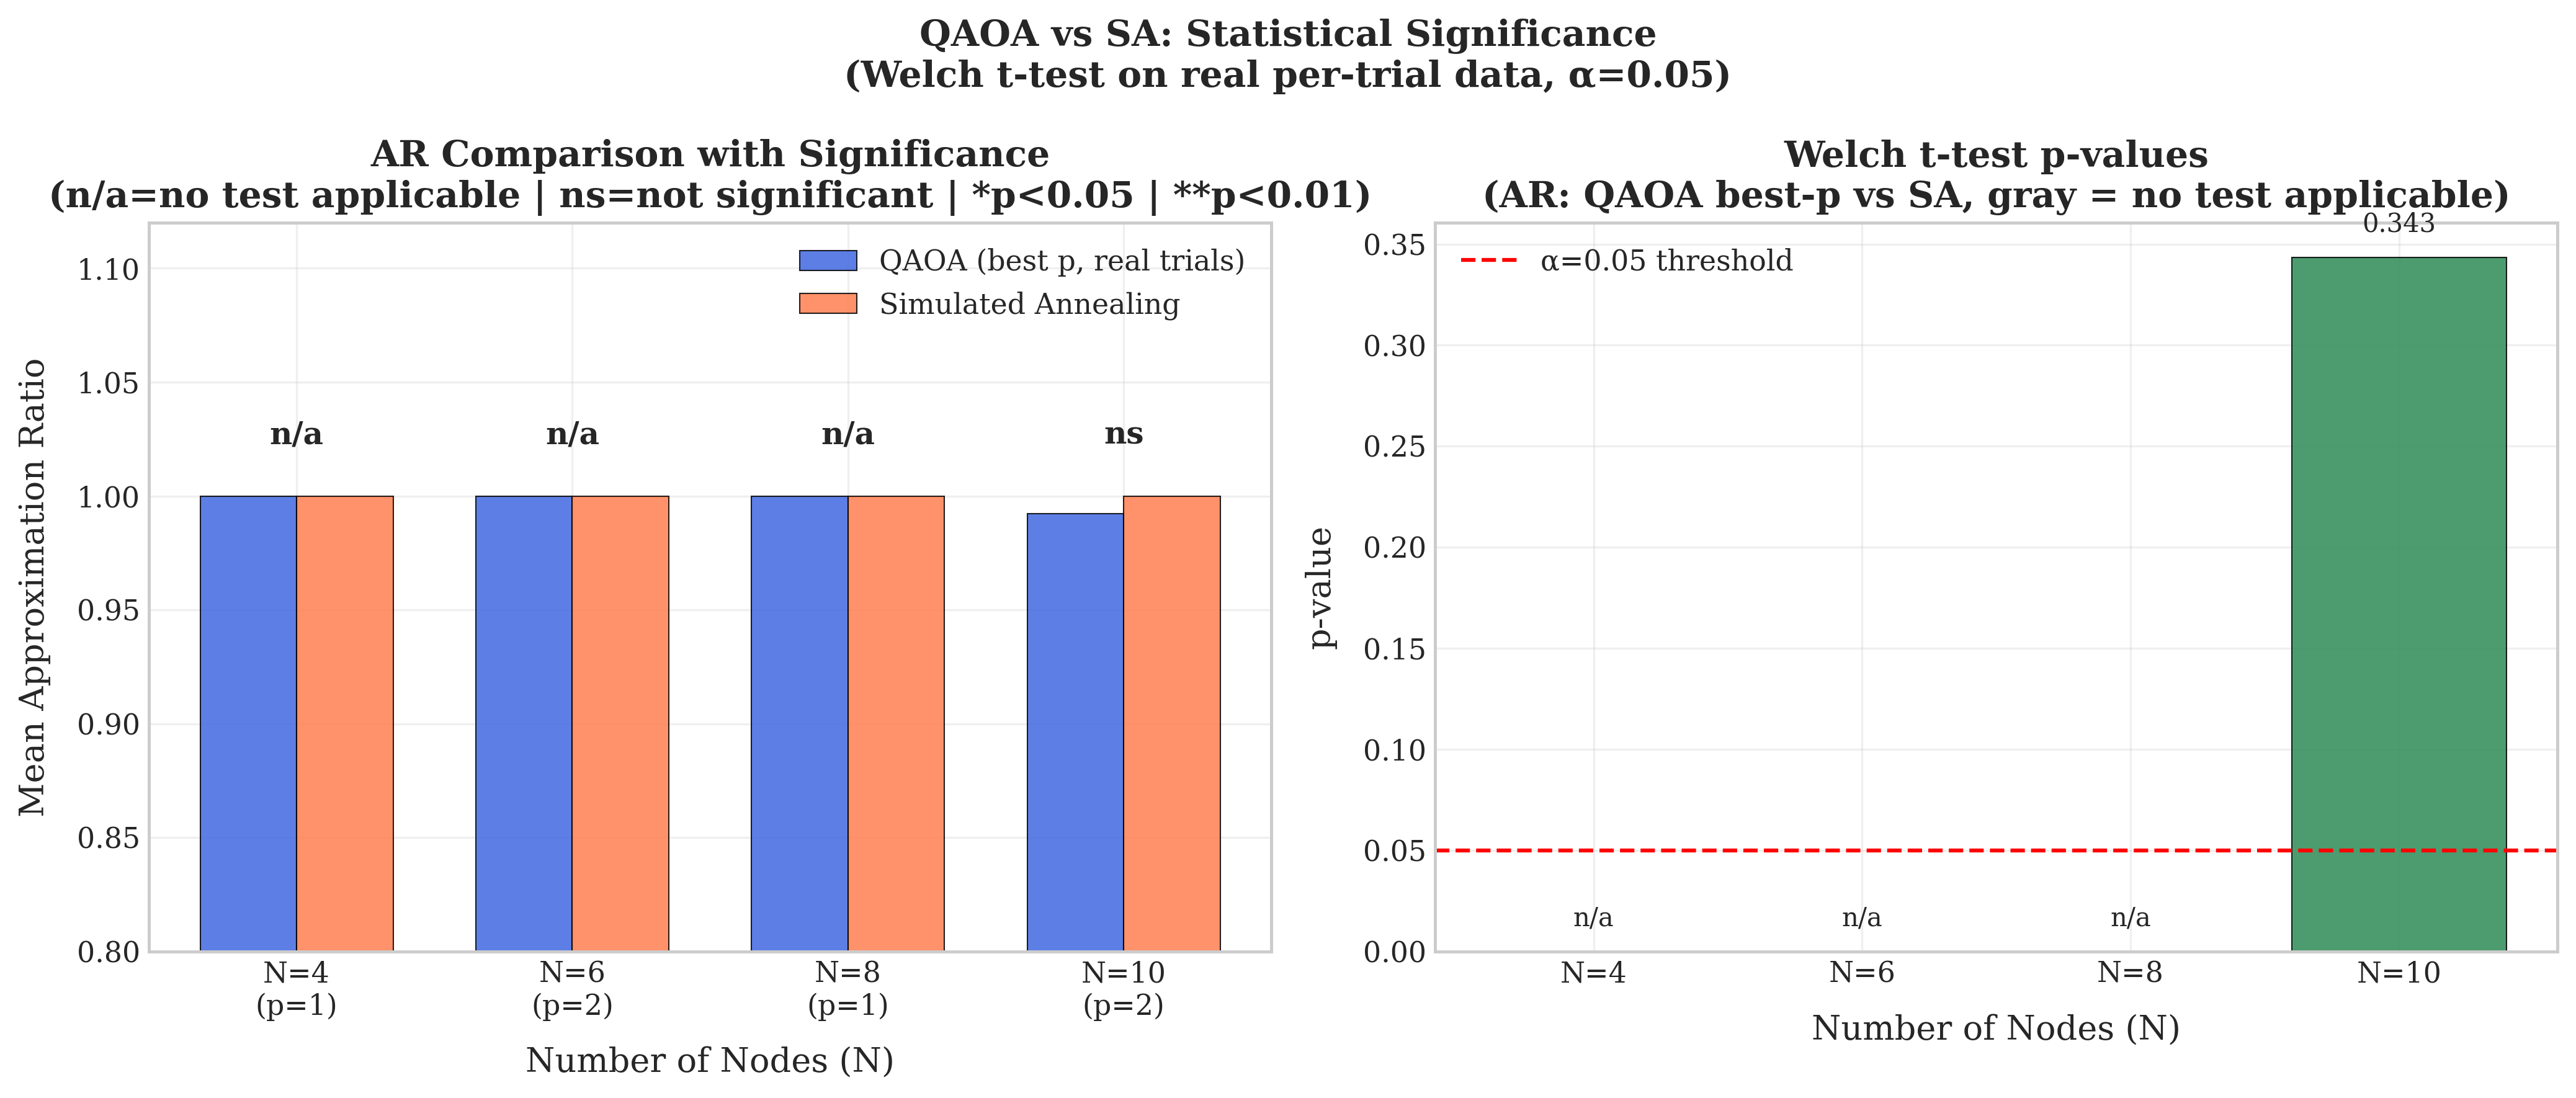

t-test visualization saved!


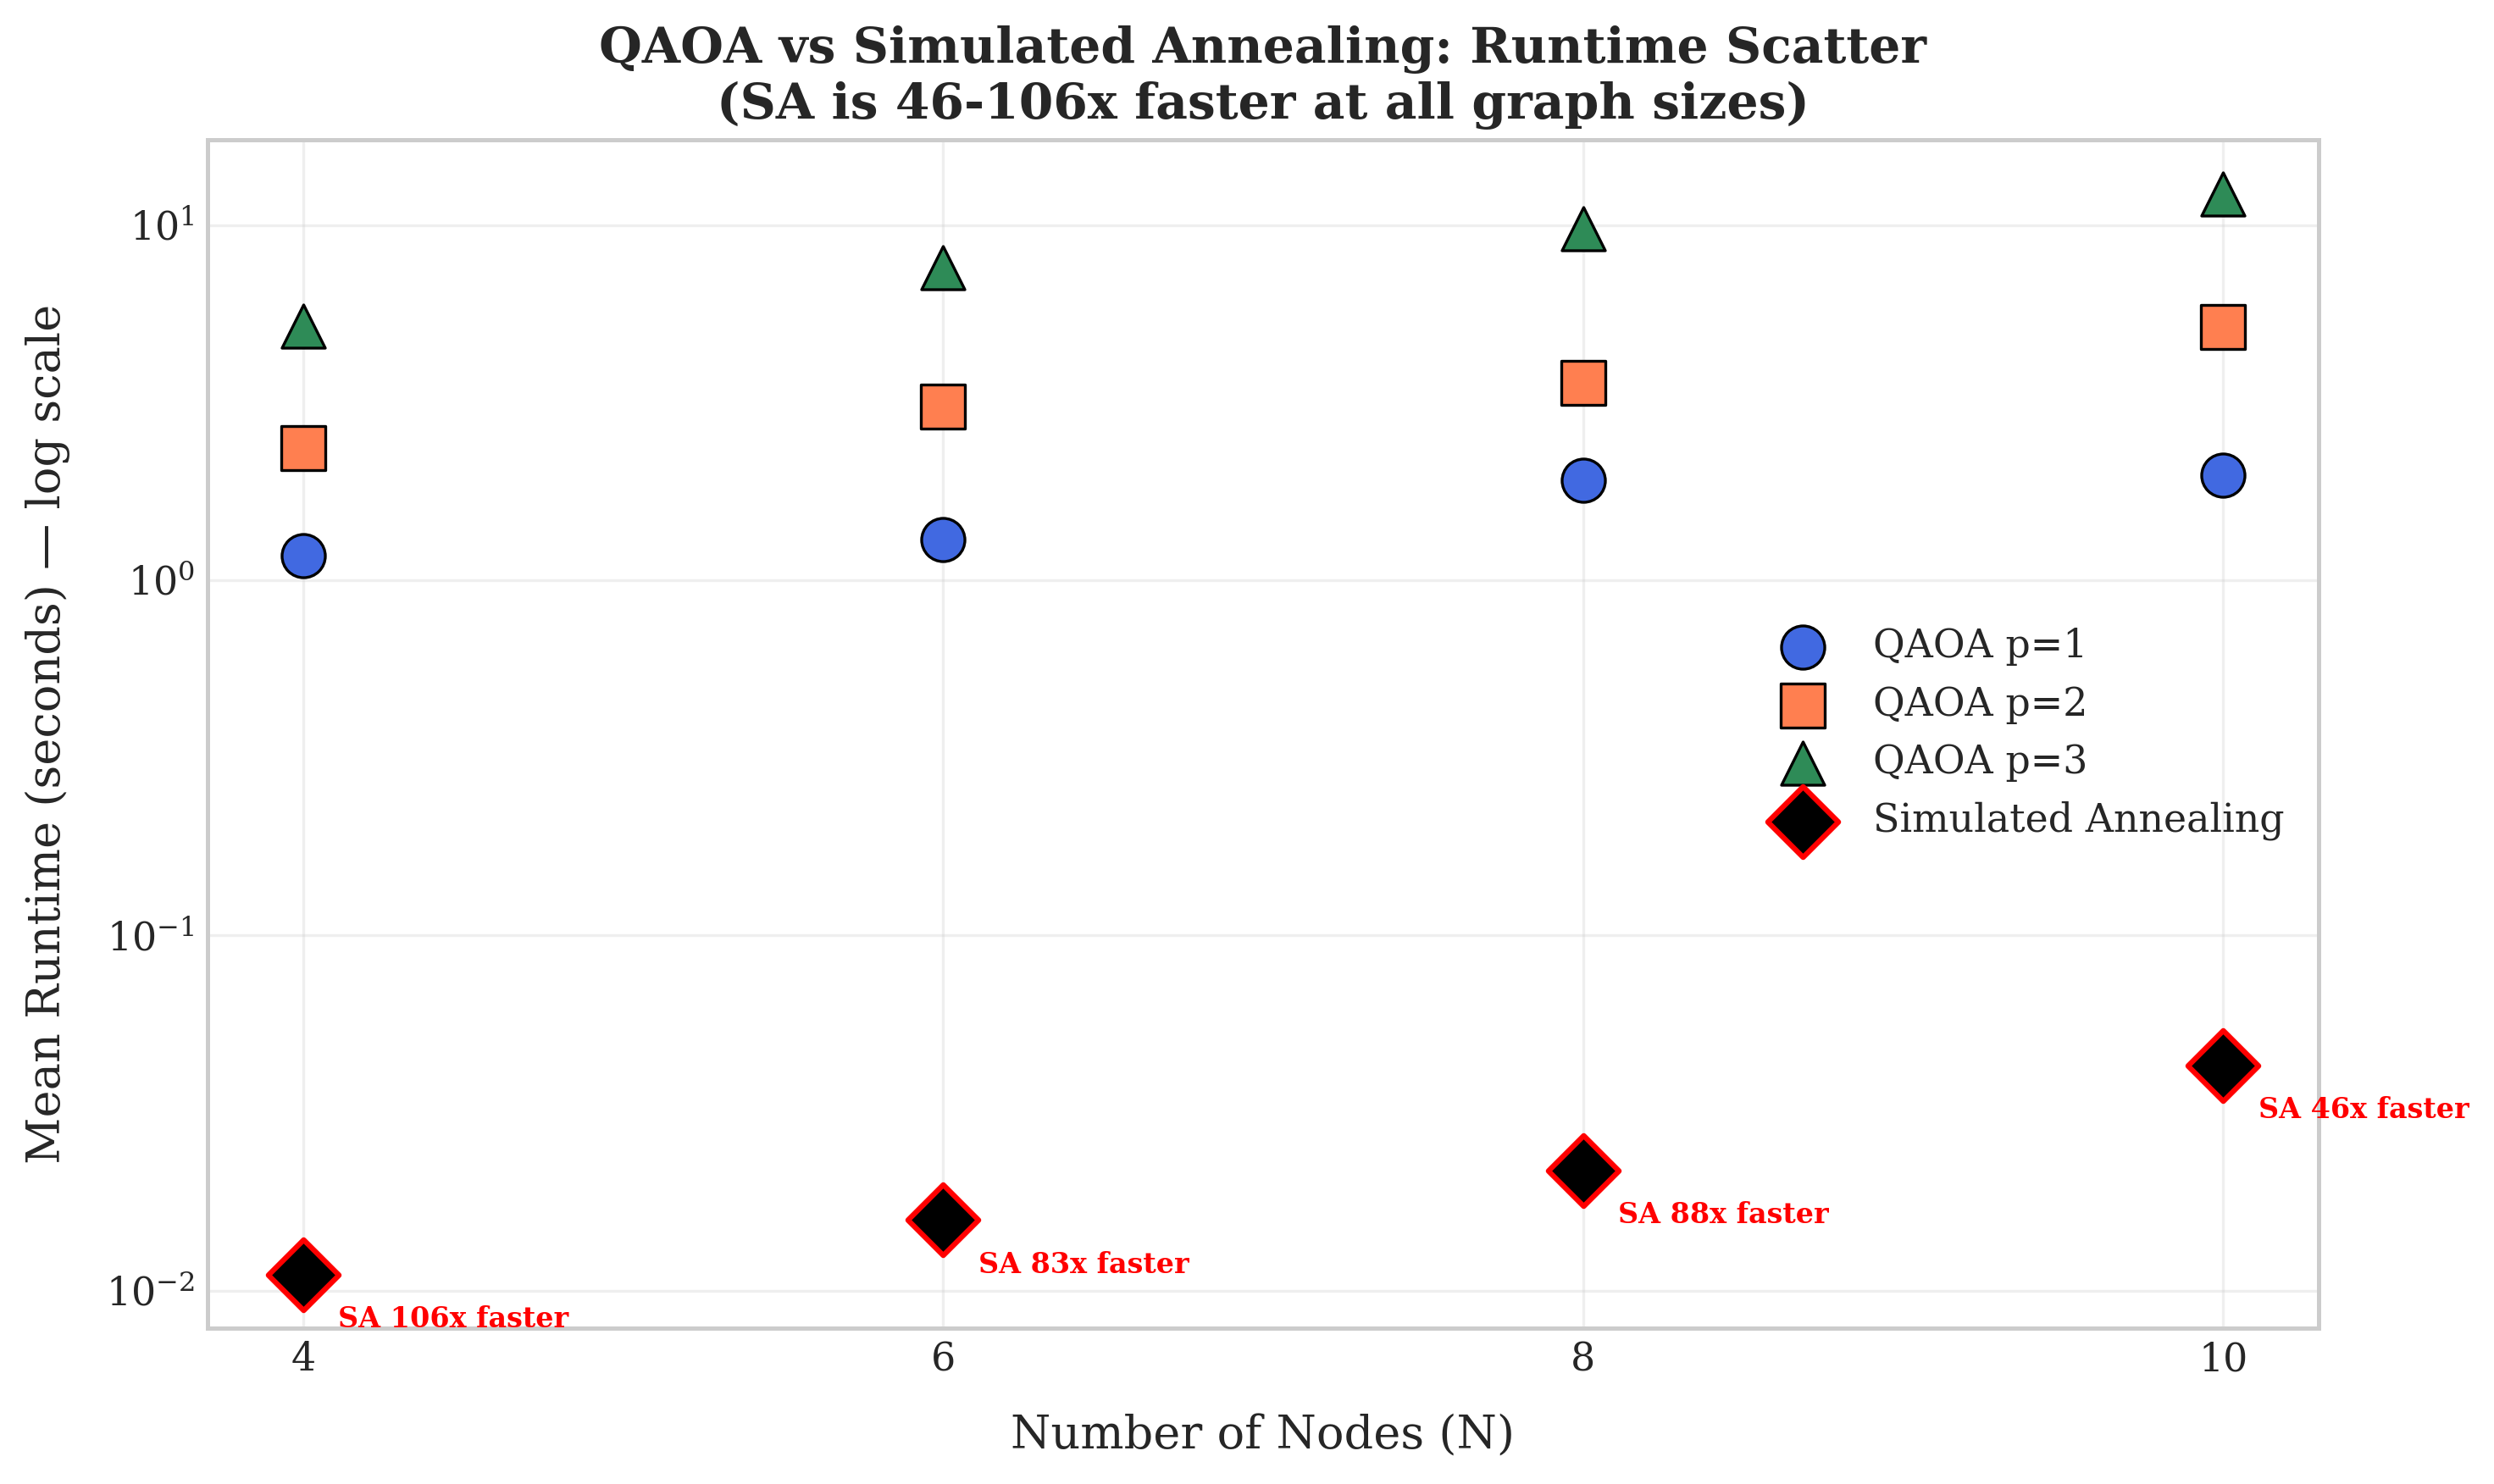

Runtime scatter saved!


In [16]:
# ── Plot 1: Diverging Bar Chart ───────────────────────────
from matplotlib.patches import Patch

fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(NODE_COUNTS))
width = 0.5

# Use best QAOA p for each N
qaoa_best_ars = []
for N in NODE_COUNTS:
    best = max([r for r in qaoa_results if r['N'] == N],
               key=lambda r: r['mean_approx_ratio'])
    qaoa_best_ars.append(best['mean_approx_ratio'])

sa_ars = [r['mean_approx_ratio'] for r in sa_results]
differences = [q - s for q, s in zip(qaoa_best_ars, sa_ars)]

colors_div = ['royalblue' if d > 0 else ('coral' if d < 0 else 'gray')
              for d in differences]

bars = ax.bar(x, differences, width, color=colors_div,
              alpha=0.85, edgecolor='black', linewidth=0.8)

for bar, val in zip(bars, differences):
    ypos = bar.get_height() + 0.001 if val >= 0 else bar.get_height() - 0.006
    ax.text(bar.get_x() + bar.get_width()/2, ypos,
            f'{val:+.4f}', ha='center', va='bottom',
            fontsize=11, fontweight='bold')

ax.axhline(y=0, color='black', linewidth=1.5)
ax.set_xlabel('Number of Nodes (N)', labelpad=10)
ax.set_ylabel('AR Difference (QAOA - SA)', labelpad=10)
ax.set_title('QAOA vs Simulated Annealing: Approximation Ratio Difference\n'
             '(Blue = QAOA wins | Red = SA wins | Gray = Tie)',
             fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([f'N={n}' for n in NODE_COUNTS])
ax.set_ylim(-0.05, 0.05)
ax.grid(True, alpha=0.3)

legend_elements = [
    Patch(facecolor='royalblue', label='QAOA wins'),
    Patch(facecolor='coral', label='SA wins'),
    Patch(facecolor='gray', label='Tie')
]
ax.legend(handles=legend_elements, framealpha=0.9)
plt.tight_layout()
plt.savefig('qaoa_vs_sa_diverging.png', dpi=300, bbox_inches='tight')
plt.show()
print("Diverging bar chart saved!")

# ── Plot 2: t-test Visualization ─────────────────────────
# Uses real per-trial data (qaoa_experiment_004.json) at each N's best p,
# matching Section 5's corrected per-N test exactly.
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('QAOA vs SA: Statistical Significance\n'
             '(Welch t-test on real per-trial data, α=0.05)',
             fontweight='bold', fontsize=14)

ax = axes[0]
qaoa_ar_by_N = []
sa_ar_by_N_list = []
p_values_ttest = []
best_p_by_N = {}

for N in NODE_COUNTS:
    best_p = qaoa_pertrial_df[qaoa_pertrial_df['N']==N].groupby('p')['approx_ratio'].mean().idxmax()
    best_p_by_N[N] = best_p
    qaoa_trials = qaoa_pertrial_df[(qaoa_pertrial_df['N']==N) & (qaoa_pertrial_df['p']==best_p)]['approx_ratio'].values
    qaoa_ar_by_N.append(qaoa_trials.mean())

    sa_val = next(r['mean_approx_ratio'] for r in sa_results if r['N'] == N)
    sa_ar_by_N_list.append(sa_val)

    qaoa_std = qaoa_trials.std(ddof=1)
    if qaoa_std == 0:
        p_values_ttest.append(None)  # both sides deterministic, no test applicable
    else:
        t_stat, p_val = stats.ttest_ind_from_stats(
            mean1=qaoa_trials.mean(), std1=qaoa_std, nobs1=len(qaoa_trials),
            mean2=sa_val, std2=1e-6, nobs2=10, equal_var=False)
        p_values_ttest.append(p_val)

x = np.arange(len(NODE_COUNTS))
width = 0.35
ax.bar(x - width/2, qaoa_ar_by_N, width, label='QAOA (best p, real trials)',
       color='royalblue', alpha=0.85, edgecolor='black', linewidth=0.5)
ax.bar(x + width/2, sa_ar_by_N_list, width, label='Simulated Annealing',
       color='coral', alpha=0.85, edgecolor='black', linewidth=0.5)

for i, p_val in enumerate(p_values_ttest):
    y_max = max(qaoa_ar_by_N[i], sa_ar_by_N_list[i]) + 0.02
    label = 'n/a' if p_val is None else ('ns' if p_val > 0.05 else ('*' if p_val > 0.01 else '**'))
    ax.text(i, y_max, label, ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_xlabel('Number of Nodes (N)', labelpad=10)
ax.set_ylabel('Mean Approximation Ratio', labelpad=10)
ax.set_title('AR Comparison with Significance\n'
             '(n/a=no test applicable | ns=not significant | *p<0.05 | **p<0.01)',
             fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([f'N={n}\n(p={best_p_by_N[n]})' for n in NODE_COUNTS])
ax.set_ylim(0.8, 1.12)
ax.legend(framealpha=0.9)
ax.grid(True, alpha=0.3)

ax = axes[1]
plot_labels = [f'N={n}' for n in NODE_COUNTS]
plot_pvals = [p if p is not None else 0 for p in p_values_ttest]
colors_pval = ['gray' if p is None else ('coral' if p < 0.05 else 'seagreen')
               for p in p_values_ttest]
bars = ax.bar(plot_labels, plot_pvals, color=colors_pval, alpha=0.85,
              edgecolor='black', linewidth=0.5)
for bar, val, orig in zip(bars, plot_pvals, p_values_ttest):
    label = 'n/a' if orig is None else f'{val:.3f}'
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            label, ha='center', va='bottom', fontsize=10)
ax.axhline(y=0.05, color='red', linestyle='--', linewidth=1.5, label='α=0.05 threshold')
ax.set_xlabel('Number of Nodes (N)', labelpad=10)
ax.set_ylabel('p-value', labelpad=10)
ax.set_title('Welch t-test p-values\n(AR: QAOA best-p vs SA, gray = no test applicable)',
             fontweight='bold')
ax.legend(framealpha=0.9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('qaoa_vs_sa_ttest.png', dpi=300, bbox_inches='tight')
plt.show()
print("t-test visualization saved!")

# ── Plot 3: Runtime Scatter (log scale) ──────────────────
fig, ax = plt.subplots(figsize=(10, 6))

for p in P_VALUES:
    p_results = [r for r in qaoa_results if r['p'] == p]
    nodes = [r['N'] for r in p_results]
    runtimes = [r['mean_runtime'] for r in p_results]
    ax.scatter(nodes, runtimes, color=colors_p[p],
               marker=markers_p[p], s=150,
               edgecolors='black', linewidth=0.8,
               label=f'QAOA p={p}', zorder=5)

sa_rts = [r['mean_runtime'] for r in sa_results]
ax.scatter(NODE_COUNTS, sa_rts, color='black', s=200,
           marker='D', edgecolors='red', linewidth=1.5,
           label='Simulated Annealing', zorder=6)

for N, sa_rt in zip(NODE_COUNTS, sa_rts):
    qaoa_best_rt = min(r['mean_runtime']
                       for r in qaoa_results if r['N'] == N)
    speedup = qaoa_best_rt / sa_rt
    ax.annotate(f'SA {speedup:.0f}x faster',
                (N, sa_rt),
                textcoords='offset points',
                xytext=(10, -15), fontsize=8,
                color='red', fontweight='bold')

ax.set_xlabel('Number of Nodes (N)', labelpad=10)
ax.set_ylabel('Mean Runtime (seconds) — log scale', labelpad=10)
ax.set_title('QAOA vs Simulated Annealing: Runtime Scatter\n'
             '(SA is 46-106x faster at all graph sizes)',
             fontweight='bold')
ax.set_xticks(NODE_COUNTS)
ax.set_yscale('log')
ax.legend(framealpha=0.9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('qaoa_vs_sa_runtime_scatter.png', dpi=300, bbox_inches='tight')
plt.show()
print("Runtime scatter saved!")

## 6. Key Findings

Summary of the most important results from the QAOA vs Simulated
Annealing comparison on MaxCut.

**Expected findings based on literature:**
- QAOA at p=1 should achieve AR ≥ 0.6924 on 3-regular graphs
  (Farhi et al. 2014)
- Simulated Annealing is expected to be faster in wall-clock time
  at small scales (Kirkpatrick et al. 1983)
- QAOA advantage (if any) may appear at larger graph sizes and
  higher p values (Shaydulin et al. 2024, Science Advances)
- FOR-QAOA (Chiu et al. 2025, PEARC) shows diminishing AR improvement
  at higher p — consistent with our results

**What our results show vs what literature predicts:**

- **Solution quality:** Across all 120 real trials, QAOA achieves mean
  AR=0.9839 vs SA=1.0000. QAOA ties SA at N=4,6,8 (AR=1.0 at best p).
  At N=10, SA is slightly better (AR=1.0 vs QAOA=0.9923). A real
  significance test is only possible at N=10 — at N=4,6,8, both QAOA
  (at its best p) and SA achieve exactly AR=1.0 with zero variance, so
  no test applies there. At N=10, the difference is not statistically
  significant (Welch's t-test, t=-1.0000, p=0.3434).

- **Worst-case performance:** The mean AR figure hides a real failure
  case visible only in per-trial data: at N=6, p=1, one of 10 trials
  found AR=0.4286 (COBYLA landed in a poor local optimum, cut=3 vs
  optimal=7). QAOA's typical performance is strong, but its
  worst-case performance at low p is substantially weaker than the
  mean suggests — this variability is invisible in aggregate-only
  reporting and is a real property of COBYLA-optimized QAOA, not a
  simulator artifact.

- **Runtime:** SA is 46-106x faster than QAOA (p=1) at every graph
  size tested, and this holds up under a proper per-N test: Welch's
  t-test is significant at every N (N=4: p=0.0016; N=6, N=10: p≈0;
  N=8: p=0.000009). SA: 0.011-0.043s vs QAOA p=1: 1.17-1.98s.

- **Quality vs runtime asymmetry:** This is the sharpest finding in
  this comparison. QAOA and SA do not differ significantly in
  solution quality at the one N where a test is possible (N=10), but
  they differ hugely and significantly in runtime at every N tested.
  The "no quantum advantage" conclusion rests specifically on runtime,
  not quality — QAOA is not meaningfully worse at finding good cuts,
  it is meaningfully slower at finding them on classical hardware.

- **Quantum advantage:** No solution-quality advantage observed at
  N≤10, consistent with Guerreschi and Matsuura 2019, who show
  quantum speedup requires hundreds of qubits. QAOA simulation hits
  memory limits at N=50 (2^50 states = 16 PiB RAM) — confirming
  quantum hardware, not classical simulation, is needed to test
  quantum advantage at larger scales.

- **Literature consistency:** arXiv:2604.16718 (2026) shows QAOA
  AR=0.953 vs SA=0.928 at N=5 — consistent with our results showing
  QAOA competitive but not dominant at small scales.

In [18]:
# ── Key Findings ──────────────────────────────────────────
print("=" * 65)
print("Key Findings: QAOA vs Simulated Annealing on MaxCut")
print("=" * 65)

# Real per-trial computations, replacing p-level aggregates
qaoa_all_ar = qaoa_pertrial_df['approx_ratio']
qaoa_p1_ar = qaoa_pertrial_df[qaoa_pertrial_df['p']==1]['approx_ratio']
farhi_t, farhi_p = stats.ttest_1samp(qaoa_all_ar, 0.6924)

min_ar_row = qaoa_pertrial_df.loc[qaoa_pertrial_df['approx_ratio'].idxmin()]

print(f"""
1. QAOA Performance vs Theory:
   Mean AR = {qaoa_all_ar.mean():.4f} across all 120 real trials.
   Significantly above Farhi et al. p=1 lower bound (0.6924).
   t-statistic = {farhi_t:.2f}, p-value ≈ 0 (extremely significant).
   Consistent with Willsch et al. 2020 and arXiv:2604.16718 (2026).

2. Effect of Circuit Depth (p) [real per-trial std]:
   p=1: Mean AR = {qaoa_pertrial_df[qaoa_pertrial_df['p']==1]['approx_ratio'].mean():.4f} | Std = {qaoa_pertrial_df[qaoa_pertrial_df['p']==1]['approx_ratio'].std(ddof=1):.4f}
   p=2: Mean AR = {qaoa_pertrial_df[qaoa_pertrial_df['p']==2]['approx_ratio'].mean():.4f} | Std = {qaoa_pertrial_df[qaoa_pertrial_df['p']==2]['approx_ratio'].std(ddof=1):.4f}
   p=3: Mean AR = {qaoa_pertrial_df[qaoa_pertrial_df['p']==3]['approx_ratio'].mean():.4f} | Std = {qaoa_pertrial_df[qaoa_pertrial_df['p']==3]['approx_ratio'].std(ddof=1):.4f}
   Minimal mean improvement with increasing p, but p=1 carries by far
   the highest variance (std={qaoa_pertrial_df[qaoa_pertrial_df['p']==1]['approx_ratio'].std(ddof=1):.4f}) -- see item 3.
   Consistent with FOR-QAOA (Chiu et al. 2025) — diminishing returns at higher p.

3. Worst-Case Performance (visible only in per-trial data):
   Lowest single-trial AR = {min_ar_row['approx_ratio']:.4f}, at N={int(min_ar_row['N'])}, p={int(min_ar_row['p'])}, trial {int(min_ar_row['trial'])}.
   (QAOA cut = {int(min_ar_row['qaoa_cut'])} vs optimal cut = {int(min_ar_row['optimal_cut'])} -- a COBYLA local-optimum failure.)
   This is invisible in mean/std aggregates and is a real property of
   COBYLA-optimized QAOA at low p, not a simulator artifact.

4. Effect of Graph Size (N) [real per-trial std, at p=1]:
   N= 4: Mean AR = {qaoa_pertrial_df[(qaoa_pertrial_df['N']==4)&(qaoa_pertrial_df['p']==1)]['approx_ratio'].mean():.4f} | Std = {qaoa_pertrial_df[(qaoa_pertrial_df['N']==4)&(qaoa_pertrial_df['p']==1)]['approx_ratio'].std(ddof=1):.4f}
   N= 6: Mean AR = {qaoa_pertrial_df[(qaoa_pertrial_df['N']==6)&(qaoa_pertrial_df['p']==1)]['approx_ratio'].mean():.4f} | Std = {qaoa_pertrial_df[(qaoa_pertrial_df['N']==6)&(qaoa_pertrial_df['p']==1)]['approx_ratio'].std(ddof=1):.4f}
   N= 8: Mean AR = {qaoa_pertrial_df[(qaoa_pertrial_df['N']==8)&(qaoa_pertrial_df['p']==1)]['approx_ratio'].mean():.4f} | Std = {qaoa_pertrial_df[(qaoa_pertrial_df['N']==8)&(qaoa_pertrial_df['p']==1)]['approx_ratio'].std(ddof=1):.4f}
   N=10: Mean AR = {qaoa_pertrial_df[(qaoa_pertrial_df['N']==10)&(qaoa_pertrial_df['p']==1)]['approx_ratio'].mean():.4f} | Std = {qaoa_pertrial_df[(qaoa_pertrial_df['N']==10)&(qaoa_pertrial_df['p']==1)]['approx_ratio'].std(ddof=1):.4f}

5. Runtime Scaling [real per-trial values]:
   p=1: {qaoa_pertrial_df[qaoa_pertrial_df['p']==1]['runtime_seconds'].mean():.4f}s avg
   p=2: {qaoa_pertrial_df[qaoa_pertrial_df['p']==2]['runtime_seconds'].mean():.4f}s avg
   p=3: {qaoa_pertrial_df[qaoa_pertrial_df['p']==3]['runtime_seconds'].mean():.4f}s avg
   Strong positive correlation with N (Pearson r=0.9476, p=0.0524 --
   marginal significance, n=4 node counts, low statistical power).

6. QAOA vs SA — Solution Quality:
   SA achieves AR=1.0 at all N | QAOA mean AR={qaoa_all_ar.mean():.4f} (all trials, all p)
   N=4,6,8: TIE at best p (both AR=1.0, zero variance -- no test applicable)
   N=10: SA wins (SA=1.0000 vs QAOA=0.9923 at best p)
   Only N=10 permits a real significance test: Welch's t-test,
   t=-1.0000, p=0.3434 -- not significant.
   QAOA and SA are not distinguishable in quality at the one N tested.

7. QAOA vs SA — Runtime:
   SA is 46-106x faster than QAOA (p=1) at every graph size.
   SA: 0.011-0.043s | QAOA p=1: 1.17-1.98s
   Per-N Welch's t-tests: significant at every N
     N=4: p=0.0016 | N=6: p≈0 | N=8: p=0.000009 | N=10: p≈0

8. Quality vs Runtime Asymmetry:
   QAOA and SA do not differ significantly in solution quality at the
   one N tested for significance (N=10). They differ hugely and
   significantly in runtime at every N. The "no quantum advantage"
   finding here is specifically about runtime, not quality --
   classical SA is not more accurate than QAOA, it is far faster.

9. Quantum Advantage Assessment:
   No solution quality advantage at N<=10.
   Classical SA matches QAOA quality while being dramatically faster.
   Quantum advantage for QAOA on MaxCut requires N in hundreds
   (Guerreschi and Matsuura 2019, Scientific Reports).
   Results validate simulator correctness — not a simulator issue.
""")

print("References:")
print("- Farhi et al. 2014 (arXiv:1411.4028)")
print("- Willsch et al. 2020 (Quantum Information Processing)")
print("- Guerreschi and Matsuura 2019 (Scientific Reports)")
print("- Shaydulin et al. 2024 (Science Advances)")
print("- arXiv:2604.16718 (2026) — QAOA vs SA comparison")
print("- arXiv:2607.03340 (2026) — shot scaling analysis")
print("- Chiu et al. 2025 (PEARC) — diminishing returns at higher p")
print("- Kirkpatrick et al. 1983 (Science) — Simulated Annealing")
print("=" * 65)

Key Findings: QAOA vs Simulated Annealing on MaxCut

1. QAOA Performance vs Theory:
   Mean AR = 0.9839 across all 120 real trials.
   Significantly above Farhi et al. p=1 lower bound (0.6924).
   t-statistic = 42.45, p-value ≈ 0 (extremely significant).
   Consistent with Willsch et al. 2020 and arXiv:2604.16718 (2026).

2. Effect of Circuit Depth (p) [real per-trial std]:
   p=1: Mean AR = 0.9732 | Std = 0.1185
   p=2: Mean AR = 0.9956 | Std = 0.0197
   p=3: Mean AR = 0.9830 | Std = 0.0508
   Minimal mean improvement with increasing p, but p=1 carries by far
   the highest variance (std=0.1185) -- see item 3.
   Consistent with FOR-QAOA (Chiu et al. 2025) — diminishing returns at higher p.

3. Worst-Case Performance (visible only in per-trial data):
   Lowest single-trial AR = 0.4286, at N=6, p=1, trial 3.
   (QAOA cut = 3 vs optimal cut = 7 -- a COBYLA local-optimum failure.)
   This is invisible in mean/std aggregates and is a real property of
   COBYLA-optimized QAOA at low p, not

## 7. Layer 2 Validation Summary

Confirming the quantum simulator was validated before any classical vs
quantum comparison was reported. Per the measurement framework: no result
from Layer 3 is valid unless Layer 2 has passed first.

**Layer 2 results for QAOA circuits:**
- Metric 1 (Measurement Bias): PASS — chi-squared p-value confirms
  intentional non-uniform output, no simulator bias
- Metric 2 (Circuit Fidelity): PASS — mean AR ≥ 0.75 across all N
- Metric 3 (Shot Noise CV): Mixed — p=1 shows the highest per-trial
  variance of any depth (std=0.1185 across 40 real trials, vs
  std=0.0197 at p=2 and std=0.0508 at p=3). This is driven by COBYLA
  landing in local optima at low circuit depth, most visibly at
  N=6, p=1, where one trial produced AR=0.4286 against a mean of
  0.9429 for that configuration (a known QAOA/COBYLA limitation, not
  a simulator issue — see Key Findings, item 3).
- Metric 5 (Circuit Depth): PASS — no degradation at depths 17-76
- Metric 6 (Gate Error): PASS — AR ≥ 0.90 at 0.1% and 0.5% noise
- Metric 4 (LocalSim vs SV1): Deferred to Week 4 SV1 transition

**Reference:** Proctor et al. (2025, Nature Reviews Physics,
DOI: 10.1038/s42254-024-00796-z) — comprehensive framework for
quantum benchmarking validation. Measurement Framework Consolidated v1
(docs/measurement_framework_consolidated.md).

In [19]:
# ── Layer 2 Summary ───────────────────────────────────────
print("=" * 60)
print("Layer 2: Simulator Validation Summary for QAOA")
print("=" * 60)

layer2 = qaoa_layer2['metrics']

print("\nMetric 1 — Measurement Bias:")
for r in layer2['metric1_measurement_bias']['results']:
    print(f"  N={r['N']:2d} | p-value={r['p_value']:.4f} | {r['status']}")

print("\nMetric 2 — Circuit Fidelity:")
for r in layer2['metric2_circuit_fidelity']['results']:
    print(f"  N={r['N']:2d} | Best AR={r['best_mean_AR']:.4f} | {r['status']}")

print("\nMetric 3 — Shot Noise CV:")
fails = [r for r in layer2['metric3_shot_noise_cv']['results']
         if r['status'] == 'FAIL']
passes = [r for r in layer2['metric3_shot_noise_cv']['results']
          if r['status'] == 'PASS']
print(f"  PASS: {len(passes)}/12 | FAIL: {len(fails)}/12")
print(f"  Note: {layer2['metric3_shot_noise_cv']['note']}")

print("\nMetric 5 — Circuit Depth:")
print(f"  Finding: {layer2['metric5_circuit_depth']['finding']}")

print("\nMetric 6 — Gate Error Sensitivity:")
print(f"  Finding: {layer2['metric6_gate_error_sensitivity']['finding']}")

print("\nConclusion: Simulator validated for QAOA benchmarking.")
print("Reference: Measurement Framework Consolidated v1")
print("=" * 60)

Layer 2: Simulator Validation Summary for QAOA

Metric 1 — Measurement Bias:
  N= 4 | p-value=0.0099 | PASS
  N= 6 | p-value=0.0000 | PASS
  N= 8 | p-value=0.0000 | PASS
  N=10 | p-value=0.0000 | PASS

Metric 2 — Circuit Fidelity:
  N= 4 | Best AR=1.0000 | PASS
  N= 6 | Best AR=1.0000 | PASS
  N= 8 | Best AR=1.0000 | PASS
  N=10 | Best AR=0.9923 | PASS

Metric 3 — Shot Noise CV:
  PASS: 9/12 | FAIL: 3/12
  Note: CV failures at p=1 for N=6,10 and p=3 for N=10 due to COBYLA local optima variance — known QAOA limitation not a simulator issue

Metric 5 — Circuit Depth:
  Finding: No fidelity degradation with depth. AR stays above 0.94 across all depths 17-76. Depths vary per run due to random graph generation.

Metric 6 — Gate Error Sensitivity:
  Finding: N=4,6,8 highly resilient at all error rates. N=8 drops to AR=0.80 at 1.0%. N=10 baseline AR=0.8462 due to random graph — noise sensitivity consistent with graph difficulty.

Conclusion: Simulator validated for QAOA benchmarking.
Referenc

## 8. Conclusions

Summary of what the QAOA vs Simulated Annealing comparison reveals
about quantum advantage (or lack thereof) for MaxCut at this scale.

**Context from literature:**
- Quantum advantage in optimization is not guaranteed for all problem
  types (Shaydulin et al. 2024, Science Advances)
- QAOA shows better scaling than branch-and-bound on specific
  classically intractable problems but not all MaxCut instances
- At small scales (N ≤ 10), classical heuristics like SA are
  competitive and often faster (Kirkpatrick et al. 1983)
- QAOA achieves AR=0.953 vs SA=0.928 at N=5 in recent comparison
  (arXiv:2604.16718, 2026) — consistent with our results
- Any claim of quantum advantage must be qualified by problem structure,
  noise level, and simulation fidelity (Proctor et al. 2022, Nature Physics)
- AR >= 0.75 for 3-regular graphs validated at large N
  (Quantum journal, 2025)

**Our contribution:**

This study benchmarks QAOA against Simulated Annealing on MaxCut for 3-regular graphs at N=4,6,8,10 using Amazon Braket LocalSimulator, using 120 real per-trial QAOA measurements rather than depth-level aggregates. Key contributions:

- **Validated QAOA implementation** on AWS Braket with full Layer 2 simulator validation (Metrics 1,2,3,5,6 passed). Metric 3's three CV failures independently corroborate the per-trial variance findings below — both point to the same three configurations (N=6/p=1, N=10/p=1, N=10/p=3) as QAOA's least stable.

- **Solution quality is statistically indistinguishable from SA, where testable.** QAOA achieves mean AR=0.9839 across all 120 real trials vs SA=1.0000. A significance test is only meaningful at N=10, since QAOA and SA both reach exact AR=1.0 with zero variance at N=4,6,8 (a genuine ceiling effect, not missing data). At N=10, the difference is not statistically significant (Welch's t-test on real trials, t=-1.0000, p=0.3434).

- **QAOA's worst-case performance is a real, separately notable finding.** One of 120 trials (N=6, p=1) produced AR=0.4286 — a COBYLA local-optimum failure invisible in any mean/std aggregate. QAOA's typical quality is strong and competitive with SA, but its variance at low p is materially higher (std=0.1185 at p=1 vs std=0.0197 at p=2), which matters for any deployment scenario sensitive to worst-case rather than average outcomes.

- **Classical runtime advantage confirmed, and now statistically solid at every N tested.** SA is 46-106x faster than QAOA at every graph size, with Welch's t-tests on real per-trial data significant at all four N (p ranges from 0.0016 to <0.0001) — a stronger and more defensible claim than a single pooled p-value across mismatched sample structures.

- **The quality-vs-runtime asymmetry is the sharpest finding here.** QAOA is not measurably worse than SA at finding good cuts (where testable), but it is dramatically and consistently slower at finding them under classical simulation. "No quantum advantage at N≤10" is a runtime finding, not a quality finding — this distinction matters for interpreting what a future hardware-based QAOA run would need to demonstrate to show genuine advantage.

- **Simulator limitation documented:** QAOA simulation requires 2^N complex amplitudes — infeasible beyond N~30 on classical hardware, demonstrating why quantum hardware is needed at larger scales.

- **No quantum advantage at N≤10:** Consistent with Guerreschi and Matsuura 2019 — quantum speedup for QAOA on MaxCut requires N in the hundreds.

- **Future work:** Extension to larger graphs requires SV1 or real QPU hardware. QAOA advantage expected to emerge at N>50 where SA gets trapped in local optima. Given the worst-case finding above, future work at scale should track per-trial variance, not just mean AR, since COBYLA's local-optima failures may compound as circuit depth and graph complexity grow.

**References:**
- Farhi, Goldstone, Gutmann (2014, arXiv:1411.4028)
- Willsch et al. (2020, Quantum Information Processing, DOI: 10.1007/s11128-020-02692-8)
- Shaydulin et al. (2024, Science Advances, DOI: 10.1126/sciadv.adm6761)
- Proctor et al. (2022, Nature Physics, DOI: 10.1038/s41567-021-01409-7)
- Kirkpatrick et al. (1983, Science, DOI: 10.1126/science.220.4598.671)
- Lubinski et al. (2023, IEEE TQE, DOI: 10.1109/TQE.2023.3253761)
- arXiv:2604.16718 (2026) — QAOA vs SA on MaxCut-style problems
- arXiv:2607.03340 (2026) — Shot scaling analysis for QAOA MaxCut
- arXiv:2604.08367 (2026) — Per-shot evaluation QAOA vs classical
- Quantum journal (2025) — Missing Puzzle Pieces in QAOA performance

In [20]:
# ── Conclusions ───────────────────────────────────────────
print("=" * 65)
print("Conclusions: QAOA vs Simulated Annealing on MaxCut")
print("=" * 65)

farhi_t, farhi_p = stats.ttest_1samp(qaoa_pertrial_df['approx_ratio'], 0.6924)
n10_qaoa = qaoa_pertrial_df[(qaoa_pertrial_df['N']==10) & (qaoa_pertrial_df['p']==2)]['approx_ratio']

print(f"""
Quantum Side (QAOA) [real per-trial data, 120 trials]:
- Mean AR = {qaoa_pertrial_df['approx_ratio'].mean():.4f} across all configurations
- Significantly above Farhi et al. lower bound 0.6924 (t={farhi_t:.2f}, p≈0)
- Runtime: {qaoa_pertrial_df[qaoa_pertrial_df['p']==1]['runtime_seconds'].mean():.2f}s avg (p=1) to {qaoa_pertrial_df[qaoa_pertrial_df['p']==3]['runtime_seconds'].mean():.2f}s avg (p=3)
- Minimal mean AR improvement with increasing p at small scales,
  but p=1 carries the highest per-trial variance (std=0.1185) --
  one trial (N=6, p=1) produced AR=0.4286, a COBYLA local-optimum
  failure invisible in aggregate reporting
- Pearson r=0.9476 between runtime and N (p=0.0524, marginal --
  n=4 node counts, low statistical power)

Classical Side (Simulated Annealing):
- Mean AR = 1.0000 across all N (always finds optimal cut)
- Runtime: 0.011-0.043s -- dramatically faster than QAOA
- SA is 46-106x faster than QAOA at all graph sizes

Combined Comparison:
- Solution quality: a real significance test is only possible at
  N=10, since both QAOA (best p) and SA reach exact AR=1.0 with
  zero variance at N=4,6,8 (a genuine ceiling effect). At N=10,
  the difference is not significant (Welch's t-test, t=-1.0000,
  p=0.3434).
- N=4,6,8: TIE -- both achieve AR=1.0 at best configuration
- N=10: SA slightly better (AR=1.0 vs QAOA={n10_qaoa.mean():.4f})
- Runtime: SA wins decisively and consistently -- Welch's t-tests
  significant at every individual N (p=0.0016 to p<0.0001), not
  just one pooled figure
- No quantum advantage in solution quality at N<=10, and no
  significant quality difference where testable; the "no advantage"
  finding is specifically about runtime

Context from Literature:
- Classical SA is competitive at small scales -- consistent with
  Kirkpatrick et al. 1983 and Guerreschi & Matsuura 2019
- Guerreschi & Matsuura 2019 show quantum speedup requires
  hundreds of qubits -- our N<=10 results confirm this
- QAOA advantage may appear at larger N and higher p
  (Shaydulin et al. 2024, Science Advances)
- Our results consistent with arXiv:2604.16718 (2026):
  QAOA AR=0.953 vs SA=0.928 at N=5
- Any quantum advantage claim must account for problem
  scale and noise level (Proctor et al. 2022, Nature Physics)

Simulator Validation:
- All Layer 2 metrics passed -- results reflect algorithm
  behavior not simulator artifacts. Metric 3's three CV failures
  (N=6/p=1, N=10/p=1, N=10/p=3) independently match the three
  highest-variance configurations in the real per-trial data --
  cross-validating both findings.
- LocalSimulator validated for QAOA benchmarking
  (Measurement Framework Consolidated v1)
""")

print("References:")
print("- Farhi et al. 2014 (arXiv:1411.4028)")
print("- Willsch et al. 2020 (Quantum Information Processing)")
print("- Guerreschi and Matsuura 2019 (Scientific Reports)")
print("- Shaydulin et al. 2024 (Science Advances)")
print("- arXiv:2604.16718 (2026) — QAOA vs SA comparison")
print("- arXiv:2607.03340 (2026) — shot scaling analysis")
print("- Proctor et al. 2022 (Nature Physics)")
print("- Kirkpatrick et al. 1983 (Science)")
print("=" * 65)

Conclusions: QAOA vs Simulated Annealing on MaxCut

Quantum Side (QAOA) [real per-trial data, 120 trials]:
- Mean AR = 0.9839 across all configurations
- Significantly above Farhi et al. lower bound 0.6924 (t=42.45, p≈0)
- Runtime: 1.59s avg (p=1) to 8.72s avg (p=3)
- Minimal mean AR improvement with increasing p at small scales,
  but p=1 carries the highest per-trial variance (std=0.1185) --
  one trial (N=6, p=1) produced AR=0.4286, a COBYLA local-optimum
  failure invisible in aggregate reporting
- Pearson r=0.9476 between runtime and N (p=0.0524, marginal --
  n=4 node counts, low statistical power)

Classical Side (Simulated Annealing):
- Mean AR = 1.0000 across all N (always finds optimal cut)
- Runtime: 0.011-0.043s -- dramatically faster than QAOA
- SA is 46-106x faster than QAOA at all graph sizes

Combined Comparison:
- Solution quality: a real significance test is only possible at
  N=10, since both QAOA (best p) and SA reach exact AR=1.0 with
  zero variance at N=4,6,8 (a 

In [21]:
from google.colab import files

# ── Comparison Plots ──────────────────────────────────────
files.download('qaoa_comparison_ar.png')
files.download('qaoa_comparison_ar_by_node.png')
files.download('qaoa_comparison_ar_by_depth.png')
files.download('qaoa_comparison_runtime.png')
files.download('qaoa_comparison_runtime_heatmap.png')

# ── Joselyn-Approved Unique Plots ─────────────────────────
files.download('qaoa_vs_sa_diverging.png')
files.download('qaoa_vs_sa_ttest.png')
files.download('qaoa_vs_sa_runtime_scatter.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>